In [ ]:
# =========================================================
# Dokumentasi Lingkungan Komputasi (Google Colab)
# =======================================================...........==
import sys, platform, subprocess, importlib
import importlib.metadata as md

print("="*55)
print("SPESIFIKASI LINGKUNGAN KOMPUTASI")
print("="*55)

# 1. Python & Sistem Operasi
print("Python         :", sys.version.split()[0])
print("OS             :", subprocess.getoutput("cat /etc/os-release | grep PRETTY_NAME").split('=')[-1].strip('\"'))

# 2. CPU
import multiprocessing
print("Jumlah vCPU    :", multiprocessing.cpu_count())
print("Model CPU      :", subprocess.getoutput("cat /proc/cpuinfo | grep 'model name' | head -1").split(':')[-1].strip())

# 3. RAM & Disk
ram = int(subprocess.getoutput("grep MemTotal /proc/meminfo").split()[1]) / 1e6
print(f"RAM Sistem     : {ram:.1f} GB")
print("Disk           :", subprocess.getoutput("df -h / | awk 'NR==2{print $2}'"))

# 4. GPU
print("-"*55)
gpu = subprocess.getoutput("nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv,noheader")
print("GPU            :", gpu)
print("-"*55)

# 5. Versi Library Utama (untuk reproducibility)
def get_ver(mod, *dists):
    for dstr in dists:
        try: return md.version(dstr)
        except Exception: pass
    try: return getattr(importlib.import_module(mod), "__version__", "?")
    except Exception: return "(tidak terpasang)"

print("VERSI LIBRARY:")
print(f"  scikit-learn : {get_ver('sklearn','scikit-learn')}")
print(f"  nltk         : {get_ver('nltk','nltk')}")
print(f"  Sastrawi     : {get_ver('Sastrawi','Sastrawi','PySastrawi')}")
print(f"  rouge-score  : {get_ver('rouge_score','rouge-score')}")
print(f"  pandas       : {get_ver('pandas','pandas')}")
print(f"  numpy        : {get_ver('numpy','numpy')}")
print(f"  matplotlib   : {get_ver('matplotlib','matplotlib')}")
print(f"  seaborn      : {get_ver('seaborn','seaborn')}")
print(f"  joblib       : {get_ver('joblib','joblib')}")

SPESIFIKASI LINGKUNGAN KOMPUTASI
Python         : 3.12.13
OS             : Ubuntu 22.04.5 LTS
Jumlah vCPU    : 2
Model CPU      : Intel(R) Xeon(R) CPU @ 2.20GHz
RAM Sistem     : 13.3 GB
Disk           : 108G
-------------------------------------------------------
GPU            : /bin/sh: 1: nvidia-smi: not found
-------------------------------------------------------
VERSI LIBRARY:
  scikit-learn : 1.6.1
  nltk         : 3.9.1
  Sastrawi     : (tidak terpasang)
  rouge-score  : (tidak terpasang)
  pandas       : 2.2.3
  numpy        : 2.0.2
  matplotlib   : 3.10.0
  seaborn      : 0.13.2
  joblib       : 1.5.3


# 0. Instalasi dan Import Library

In [ ]:
!pip install PySastrawi nltk scikit-learn openpyxl rouge-score pandas numpy matplotlib seaborn --quiet

import nltk
nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)
nltk.download('stopwords',    quiet=True)

print('Semua library berhasil diinstal dan diunduh.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 8.2 MB/s eta 0:00:00
Semua library berhasil diinstal dan diunduh.


In [ ]:
# === STANDARD ===
import pandas as pd
import numpy as np
import re, json, urllib.request, warnings
warnings.filterwarnings('ignore')

# === VISUALISASI ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# === NLP ===
from nltk.tokenize import word_tokenize
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# === MACHINE LEARNING ===
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

# === EVALUASI KUALITAS RESPONS ===
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from nltk.translate.meteor_score import meteor_score

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


# 1. Data Collection

In [ ]:
# Upload file
from google.colab import files
print('Silakan upload file Dataset Chatbot.xlsx')
uploaded = files.upload()

Silakan upload file Dataset Chatbot.xlsx


Saving Dataset_Chatbot_v8.xlsx to Dataset_Chatbot_v8.xlsx


In [ ]:
# Load dataset
df = pd.read_excel('Dataset_Chatbot_v8.xlsx')
df.columns = df.columns.str.strip().str.lower()

# Pastikan kolom yang dibutuhkan ada
required = ['utterance', 'intent', 'jawaban']
assert all(c in df.columns for c in required), f"Kolom wajib: {required}"

df = df[['no', 'utterance', 'intent', 'jawaban']].copy()
df = df.dropna(subset=['utterance', 'intent', 'jawaban']).reset_index(drop=True)
df['utterance'] = df['utterance'].astype(str).str.strip()
df['jawaban']   = df['jawaban'].astype(str).str.strip()
df['intent']    = df['intent'].astype(str).str.strip()

print(f'Dataset dimuat: {len(df)} baris')
print(f'Kolom         : {list(df.columns)}')
print(f'\nPreview:')
display(df.head(5))

Dataset dimuat: 1505 baris
Kolom         : ['no', 'utterance', 'intent', 'jawaban']

Preview:


,no,utterance,intent,jawaban
0,1,"mohon info ya, siang",salam_pembuka,☀ Selamat siang! Kami siap membantu 😊 Silakan ...
1,2,Assalamualaikum permisi ya,salam_pembuka,🙏 Wa'alaikumsalam! Selamat datang di Puskesmas...
2,3,permisi aku mau bertanya,salam_pembuka,👋 Halo! Selamat datang di layanan informasi Pu...
3,4,Selaamt siang puskesmas,salam_pembuka,☀ Selamat siang! Kami siap membantu 😊 Silakan ...
4,5,"permisi kak, mau tanya. terima kasih banyak",salam_pembuka,😊 Sama-sama! Semoga informasinya bermanfaat. J...


In [ ]:
# Informasi Dataset
print('\n=== INFORMASI DATASET ===')
print(df.info())

print('\n=== DISTRIBUSI INTENT ===')
dist = df['intent'].value_counts()
display(dist.to_frame('jumlah_utterance').assign(
    persentase=lambda x: (x['jumlah_utterance']/len(df)*100).round(2).astype(str)+'%'
))


=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   no         1505 non-null   int64 
 1   utterance  1505 non-null   object
 2   intent     1505 non-null   object
 3   jawaban    1505 non-null   object
dtypes: int64(1), object(3)
memory usage: 47.2+ KB
None

=== DISTRIBUSI INTENT ===


,jumlah_utterance,persentase
intent,,
keluhan_ringan,430,28.57%
info_jadwal_poli,215,14.29%
info_jadwal_pelayanan,195,12.96%
info_konseling,185,12.29%
info_syarat_daftar,170,11.3%
fallback,160,10.63%
salam_pembuka,150,9.97%


=== DISTRIBUSI INTENT ===


,jumlah,persen
intent,,
keluhan_ringan,430,28.57%
info_jadwal_poli,215,14.29%
info_jadwal_pelayanan,195,12.96%
info_konseling,185,12.29%
info_syarat_daftar,170,11.3%
fallback,160,10.63%
salam_pembuka,150,9.97%


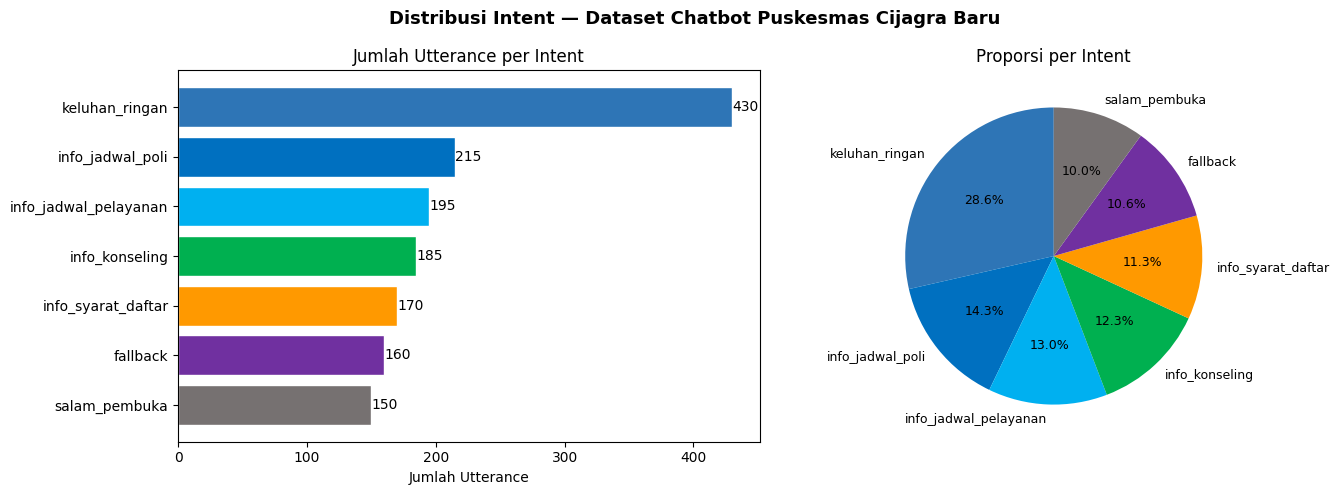

Total utterance: 1505


In [ ]:
# Distribusi Intent
dist = df['intent'].value_counts()
print('=== DISTRIBUSI INTENT ===')
display(dist.to_frame('jumlah').assign(
    persen=lambda x: (x['jumlah']/len(df)*100).round(2).astype(str)+'%'
))

COLORS = ['#2E75B6','#0070C0','#00B0F0','#00B050','#FF9900','#7030A0','#767171']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Intent — Dataset Chatbot Puskesmas Cijagra Baru',
             fontsize=13, fontweight='bold')

bars = axes[0].barh(dist.index, dist.values, color=COLORS[:len(dist)], edgecolor='white')
axes[0].set_xlabel('Jumlah Utterance')
axes[0].set_title('Jumlah Utterance per Intent')
for bar, val in zip(bars, dist.values):
    axes[0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                 str(val), va='center', fontsize=10)
axes[0].invert_yaxis()

axes[1].pie(dist.values, labels=dist.index, colors=COLORS[:len(dist)],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':9})
axes[1].set_title('Proporsi per Intent')

plt.tight_layout()
plt.savefig('distribusi_intent.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total utterance: {len(df)}')

# 2. Data Preprocessing

2.1 Load Korpus Eksternal (Slangword & Stopword)

In [ ]:
# Korpus Slangword (KBBA)
SLANG_URL = 'https://raw.githubusercontent.com/ramaprakoso/analisis-sentimen/master/kamus/kbba.txt'
slang_dict = {}
try:
    with urllib.request.urlopen(SLANG_URL) as r:
        for line in r.read().decode('utf-8').splitlines():
            parts = line.strip().split('\t')
            if len(parts) == 2:
                slang_dict[parts[0].lower()] = parts[1].lower()
    print(f'Korpus slangword berhasil dimuat: {len(slang_dict):,} entri')
except Exception as e:
    print(f'Gagal memuat dari URL ({e}), menggunakan kamus lokal minimal.')
    slang_dict = {
        'ga':'tidak','gak':'tidak','gk':'tidak','ngga':'tidak','nggak':'tidak',
        'yg':'yang','dg':'dengan','utk':'untuk','dgn':'dengan','krn':'karena',
        'brp':'berapa','brapa':'berapa','gmn':'bagaimana','gimana':'bagaimana',
        'blm':'belum','udh':'sudah','udah':'sudah','sdh':'sudah',
        'mau':'mau','mw':'mau','bs':'bisa','bisa':'bisa',
        'sm':'sama','dr':'dari','ke':'ke','pd':'pada',
        'klo':'kalau','kalo':'kalau','klau':'kalau',
        'hrs':'harus','hr':'hari','bsk':'besok','skrg':'sekarang',
        'jm':'jam','wkt':'waktu','smpe':'sampai','sampe':'sampai',
        'lg':'lagi','lg':'lagi','tp':'tapi','ttg':'tentang',
        'pk':'pukul','pkm':'puskesmas','pskesmas':'puskesmas',
        'buka':'buka','bkanya':'bukanya','bka':'buka',
        'kak':'kakak','bang':'abang','kak':'kakak',
        'aja':'saja','aj':'saja','doang':'saja',
        'juga':'juga','jg':'juga','dan':'dan',
        'pls':'please','dong':'dong','deh':'deh',
        'td':'tadi','kmrn':'kemarin','bln':'bulan','bka':'buka',
    }
    print(f'Kamus lokal dimuat: {len(slang_dict)} entri')

# Preview
sample_slang = dict(list(slang_dict.items())[:10])
print('\nContoh entri slangword:')
display(pd.DataFrame(list(sample_slang.items()), columns=['Slang','Baku']))

Korpus slangword berhasil dimuat: 1,290 entri

Contoh entri slangword:


,Slang,Baku
0,7an,tujuan
1,@,di
2,ababil,abg labil
3,abis,habis
4,acc,accord
5,ad,ada
6,adlah,adalah
7,adlh,adalah
8,adoh,aduh
9,afaik,as far as i know


In [ ]:
# Korpus Stopword Bahasa Indonesia
SW_URL = 'https://raw.githubusercontent.com/yasirutomo/python-sentianalysis-id/master/data/feature_list/stopwordsID.txt'
stopwords_id = set()
try:
    with urllib.request.urlopen(SW_URL) as r:
        for line in r.read().decode('utf-8').splitlines():
            w = line.strip().lower()
            if w:
                stopwords_id.add(w)
    print(f'Korpus stopword berhasil dimuat: {len(stopwords_id):,} kata')
except Exception as e:
    print(f'Gagal memuat dari URL ({e}), menggunakan stopword NLTK.')
    from nltk.corpus import stopwords
    stopwords_id = set(stopwords.words('indonesian'))
    print(f'Stopword NLTK dimuat: {len(stopwords_id)} kata')

# Kata-kata domain kesehatan yang TIDAK boleh dihapus
DOMAIN_KEEP = {
    'poli','puskesmas','dokter','buka','tutup','jam','hari',
    'jadwal','daftar','syarat','periksa','berobat','konseling',
    'senin','selasa','rabu','kamis','jumat','sabtu','minggu',
    'bpjs','ktp','kk','gratis','biaya','rawat','jalan',
    'imunisasi','vaksin','hamil','bayi','anak','gigi','umum',
    'lab','farmasi','obat','sakit','demam','batuk','pilek',
    'mual','diare','pusing','gatal','luka','nyeri'
}
stopwords_id = stopwords_id - DOMAIN_KEEP
print(f'Stopword setelah dikurangi kata domain: {len(stopwords_id):,} kata')
print(f'Kata domain yang dipertahankan: {len(DOMAIN_KEEP)} kata')

Korpus stopword berhasil dimuat: 757 kata
Stopword setelah dikurangi kata domain: 755 kata
Kata domain yang dipertahankan: 47 kata


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.Dictionary.ArrayDictionary import ArrayDictionary
from Sastrawi.Stemmer.Stemmer import Stemmer

# 1. Inisialisasi Factory
factory = StemmerFactory()

# 2. Ambil daftar kata dasar bawaan dari PySastrawi
base_words = factory.get_words()

# 3. Tambahkan daftar kata medis/domain khusus milik Anda
kata_medis_tambahan = [
    'poli', 'bpjs', 'mtbs', 'kia', 'kb', 'gizi',
    'catin', 'puskesmas', 'imunisasi', 'vaksin'
]
base_words.extend(kata_medis_tambahan)

# 4. Buat kamus (dictionary) baru yang sudah digabungkan
custom_dictionary = ArrayDictionary(base_words)

# 5. Inisialisasi Stemmer dengan kamus kustom Anda
stemmer = Stemmer(custom_dictionary)

print('Stemmer PySastrawi kustom berhasil diinisialisasi.')

# Mari kita test
print("Test kata 'poli'       :", stemmer.stem("poli"))
print("Test kata 'mendaftar'  :", stemmer.stem("mendaftar"))
print("Test kata 'imunisasi'  :", stemmer.stem("imunisasi"))

Stemmer PySastrawi kustom berhasil diinisialisasi.
Test kata 'poli'       : poli
Test kata 'mendaftar'  : daftar
Test kata 'imunisasi'  : imunisasi


2.2 Fungsi Preprocessing

In [ ]:
# ── Fungsi preprocessing (hanya untuk utterance) ────────────────
def step1_case_folding(text: str) -> str:
    return text.lower()

def step2_cleaning(text: str) -> str:
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    emoji_pat = re.compile(
        '[\U00010000-\U0010ffff\U0001F600-\U0001F64F'
        '\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF'
        '\U0001F1E0-\U0001F1FF]+', flags=re.UNICODE)
    return emoji_pat.sub(' ', text).strip()

def step3_normalisasi(text: str) -> str:
    return ' '.join(slang_dict.get(w, w) for w in text.split())

def step4_tokenisasi(text: str) -> list:
    return word_tokenize(text)

def step5_stopword_removal(tokens: list) -> list:
    return [w for w in tokens if w not in stopwords_id and len(w) > 1]

def step6_stemming(tokens: list) -> str:
    return ' '.join(stemmer.stem(w) for w in tokens)

def full_preprocessing(text: str) -> str:
    """Pipeline preprocessing 6 tahap — hanya untuk kolom utterance."""
    t = step1_case_folding(text)
    t = step2_cleaning(t)
    t = step3_normalisasi(t)
    tokens = step4_tokenisasi(t)
    tokens = step5_stopword_removal(tokens)
    return step6_stemming(tokens)

print('Fungsi preprocessing berhasil didefinisikan.')
print('> Kolom jawaban TIDAK dipreprocessing (emoji & format dipertahankan).')

Fungsi preprocessing berhasil didefinisikan.
> Kolom jawaban TIDAK dipreprocessing (emoji & format dipertahankan).


In [ ]:
# ── Terapkan preprocessing ke utterance saja ─────────────────────
print('Menjalankan preprocessing pada kolom utterance...')
print('(Stemming PySastrawi ~1-3 menit)\n')

df['step1'] = df['utterance'].apply(step1_case_folding)
df['step2'] = df['step1'].apply(step2_cleaning)
df['step3'] = df['step2'].apply(step3_normalisasi)
df['step4'] = df['step3'].apply(step4_tokenisasi)
df['step5'] = df['step4'].apply(step5_stopword_removal)
df['utterance_clean'] = df['step5'].apply(step6_stemming)

# ── DIAGNOSTIK: tampilkan utterance yang hilang setelah preprocessing ──
empty = df['utterance_clean'].str.strip() == ''
if empty.sum() > 0:
    print(f'⚠️  {empty.sum()} utterance kosong setelah preprocessing (akan dibuang):')
    display(df.loc[empty, ['no','utterance','intent']].reset_index(drop=True))
else:
    print('✅ Semua utterance berhasil dipreprocessing.')

df = df[~empty].reset_index(drop=True)

print(f'\nPreprocessing selesai! Total: {len(df)} baris')
print('\n=== PERBANDINGAN UTTERANCE ASLI vs PREPROCESSED ===')
display(df[['utterance','utterance_clean','intent']].sample(8, random_state=42).reset_index(drop=True))

df[['no','utterance','utterance_clean','intent','jawaban']].to_excel(
    'dataset_preprocessed.xlsx', index=False)
print('\nFile tersimpan: dataset_preprocessed.xlsx')


Menjalankan preprocessing pada kolom utterance...
(Stemming PySastrawi ~1-3 menit)

✅ Semua utterance berhasil dipreprocessing.

Preprocessing selesai! Total: 1505 baris

=== PERBANDINGAN UTTERANCE ASLI vs PREPROCESSED ===


,utterance,utterance_clean,intent
0,Met sore,met sore,salam_pembuka
1,"mohon info ya, klo gigi berlubang ke poli apa?...",mohon informasi iya gigi lubang poli mohon inf...,keluhan_ringan
2,Puskesmas buka jam berapa ya?,puskesmas buka jam iya,info_jadwal_pelayanan
3,"Saya mau tes urine, gimana carayna?",tes urine carayna,keluhan_ringan
4,"kak, mau tanya nih. konsultasi sanitasi kapan?",kak konsultasi sanitasi,info_konseling
5,"bayi aku deamm, ke mana ya?",bayi deamm iya,keluhan_ringan
6,ibu hamil kelhuan kehamilan periksa ke mana?,hamil kelhuan hamil periksa,keluhan_ringan
7,Jadwal lab kapan ka?,jadwal lab kakak,info_jadwal_poli



File tersimpan: dataset_preprocessed.xlsx


2.3 Demonstrasi Perubahan per Tahap (Contoh Kalimat)

In [ ]:
import nltk

nltk.download('punkt_tab', force=True)
nltk.download('punkt', force=True)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import nltk
import importlib
import os

from nltk.tokenize import word_tokenize

# Set NLTK_DATA environment variable
NLTK_DATA_PATH = "/root/nltk_data"
os.environ["NLTK_DATA"] = NLTK_DATA_PATH

# Ensure NLTK knows about this path and reload data path awareness early
if NLTK_DATA_PATH not in nltk.data.path:
    nltk.data.path.append(NLTK_DATA_PATH)
importlib.reload(nltk.data)

# Ensure 'punkt' is downloaded, which provides general tokenization rules
nltk.download('punkt', force=True)

# Force reload of nltk.tokenize to ensure it picks up the newly downloaded resource
importlib.reload(nltk.tokenize)

# Simplified step4_tokenisasi to use generic word_tokenize
def step4_tokenisasi(text: str) -> list:
    """Tahap 4: Memecah kalimat menjadi token kata menggunakan NLTK word_tokenize.
    Uses generic NLTK word_tokenize as Indonesian-specific Punkt models are problematic.
    """
    # Fallback to generic word_tokenize which uses English Punkt by default
    # This bypasses issues with indonesian.pickle and punkt_tab for language-specific tokenization
    return word_tokenize(text)

def full_preprocessing(text: str) -> str:
    """Pipeline preprocessing lengkap 6 tahap."""
    t = step1_case_folding(text)
    t = step2_cleaning(t)
    t = step3_normalisasi(t)
    tokens = step4_tokenisasi(t)
    tokens = step5_stopword_removal(tokens)
    return step6_stemming(tokens)

# Tampilkan perubahan bertahap untuk 5 contoh kalimat representatif
contoh = [
    'poli umum bka jam brp?? 🙏',
    'mau periksa hamil, hari apa? Syaratnya apa aja...',
    'konsling gizi kapan? bisa janji via WA ga 😅',
    'Anak saya DEMAM 3 hari, ke poli MTBS ya???',
    'HALO kak, mau TANYA jam buka puskesmas 😊😊'
]

records = []
for kalimat in contoh:
    s1 = step1_case_folding(kalimat)
    s2 = step2_cleaning(s1)
    s3 = step3_normalisasi(s2)
    s4 = step4_tokenisasi(s3)
    s5 = step5_stopword_removal(s4)
    s6 = step6_stemming(s5)
    records.append({
        'Teks Asli'         : kalimat,
        '① Case Folding'    : s1,
        '② Cleaning'        : s2,
        '③ Normalisasi'     : s3,
        '④ Tokenisasi'      : str(s4),
        '⑤ Stopword Removal': str(s5),
        '⑥ Stemming (final)': s6,
    })

df_demo = pd.DataFrame(records).T
df_demo.columns = [f'Contoh {i+1}' for i in range(len(contoh))]

print('=== DEMONSTRASI PERUBAHAN PER TAHAP PREPROCESSING ===')
display(df_demo.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),('font-weight','bold')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color','#1F4E79')]}
]))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


=== DEMONSTRASI PERUBAHAN PER TAHAP PREPROCESSING ===


,Contoh 1,Contoh 2,Contoh 3,Contoh 4,Contoh 5
Teks Asli,poli umum bka jam brp?? 🙏,"mau periksa hamil, hari apa? Syaratnya apa aja...",konsling gizi kapan? bisa janji via WA ga 😅,"Anak saya DEMAM 3 hari, ke poli MTBS ya???","HALO kak, mau TANYA jam buka puskesmas 😊😊"
① Case Folding,poli umum bka jam brp?? 🙏,"mau periksa hamil, hari apa? syaratnya apa aja...",konsling gizi kapan? bisa janji via wa ga 😅,"anak saya demam 3 hari, ke poli mtbs ya???","halo kak, mau tanya jam buka puskesmas 😊😊"
② Cleaning,poli umum bka jam brp,mau periksa hamil hari apa syaratnya apa aja,konsling gizi kapan bisa janji via wa ga,anak saya demam hari ke poli mtbs ya,halo kak mau tanya jam buka puskesmas
③ Normalisasi,poli umum bka jam berapa,mau periksa hamil hari apa syaratnya apa saja,konsling gizi kapan bisa janji via wa tidak,anak saya demam hari ke poli mtbs iya,halo kak mau tanya jam buka puskesmas
④ Tokenisasi,"['poli', 'umum', 'bka', 'jam', 'berapa']","['mau', 'periksa', 'hamil', 'hari', 'apa', 'syaratnya', 'apa', 'saja']","['konsling', 'gizi', 'kapan', 'bisa', 'janji', 'via', 'wa', 'tidak']","['anak', 'saya', 'demam', 'hari', 'ke', 'poli', 'mtbs', 'iya']","['halo', 'kak', 'mau', 'tanya', 'jam', 'buka', 'puskesmas']"
⑤ Stopword Removal,"['poli', 'umum', 'bka', 'jam']","['periksa', 'hamil', 'hari', 'syaratnya']","['konsling', 'gizi', 'janji', 'via', 'wa']","['anak', 'demam', 'hari', 'poli', 'mtbs', 'iya']","['halo', 'kak', 'jam', 'buka', 'puskesmas']"
⑥ Stemming (final),poli umum bka jam,periksa hamil hari syarat,konsling gizi janji via wa,anak demam hari poli mtbs iya,halo kak jam buka puskesmas


# 3. Ekstraksi Fitur TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi TF-IDF dengan parameter dasar untuk inspeksi
tfidf_inspect = TfidfVectorizer(ngram_range=(1,2), max_features=1000)
X_inspect     = tfidf_inspect.fit_transform(df['utterance_clean'])

feature_names = tfidf_inspect.get_feature_names_out()
df_tfidf      = pd.DataFrame(X_inspect.toarray(), columns=feature_names)

print(f'Dimensi matriks TF-IDF : {X_inspect.shape}')
print(f'Jumlah dokumen (baris) : {X_inspect.shape[0]}')
print(f'Jumlah fitur (kolom)   : {X_inspect.shape[1]}')
print(f'Sparsity               : {(1 - X_inspect.nnz / np.prod(X_inspect.shape))*100:.2f}%')

Dimensi matriks TF-IDF : (1505, 1000)
Jumlah dokumen (baris) : 1505
Jumlah fitur (kolom)   : 1000
Sparsity               : 99.35%


In [ ]:
# Tampilkan TF-IDF untuk 5 dokumen menggunakan fitur dengan bobot TERTINGGI
# (bukan 15 fitur pertama alfabet yang mungkin semua nol)

# Hitung rata-rata bobot tiap fitur di seluruh dokumen
mean_weights  = np.asarray(X_inspect.mean(axis=0)).flatten()
top15_idx     = mean_weights.argsort()[-15:][::-1]
top15_features= feature_names[top15_idx]

df_tfidf_top  = pd.DataFrame(
    X_inspect[:5, top15_idx].toarray(),
    columns=top15_features
)

print('=== PREVIEW MATRIKS TF-IDF (5 dokumen × 15 fitur BOBOT TERTINGGI) ===')
print('Nilai 0 = kata tidak muncul di dokumen; makin tinggi = makin representatif')
display(df_tfidf_top.round(4).style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.4f}')
    .set_caption('15 fitur dipilih berdasarkan rata-rata bobot TF-IDF tertinggi')
)

# Tampilkan juga top-15 kata dengan bobot rata-rata tertinggi
top15_df = pd.DataFrame({'Fitur': top15_features, 'Rata-rata TF-IDF': mean_weights[top15_idx].round(4)})
print('\n=== TOP-15 KATA DENGAN BOBOT TF-IDF RATA-RATA TERTINGGI ===')
display(top15_df.reset_index(drop=True))


=== PREVIEW MATRIKS TF-IDF (5 dokumen × 15 fitur BOBOT TERTINGGI) ===
Nilai 0 = kata tidak muncul di dokumen; makin tinggi = makin representatif


,iya,poli,hari,kak,kasih,terima,terima kasih,daftar,periksa,jam,mohon,buka,konseling,pkm,puskesmas
0,0.2010,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2742,0.0000,0.0000,0.0000,0.0000
1,0.2420,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.2828
4,0.0000,0.0000,0.0000,0.2627,0.2700,0.2700,0.2705,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000



=== TOP-15 KATA DENGAN BOBOT TF-IDF RATA-RATA TERTINGGI ===


,Fitur,Rata-rata TF-IDF
0,iya,0.0495
1,poli,0.0398
2,hari,0.0359
3,kak,0.0324
4,kasih,0.0279
5,terima,0.0279
6,terima kasih,0.0277
7,daftar,0.0271
8,periksa,0.0270
9,jam,0.0269


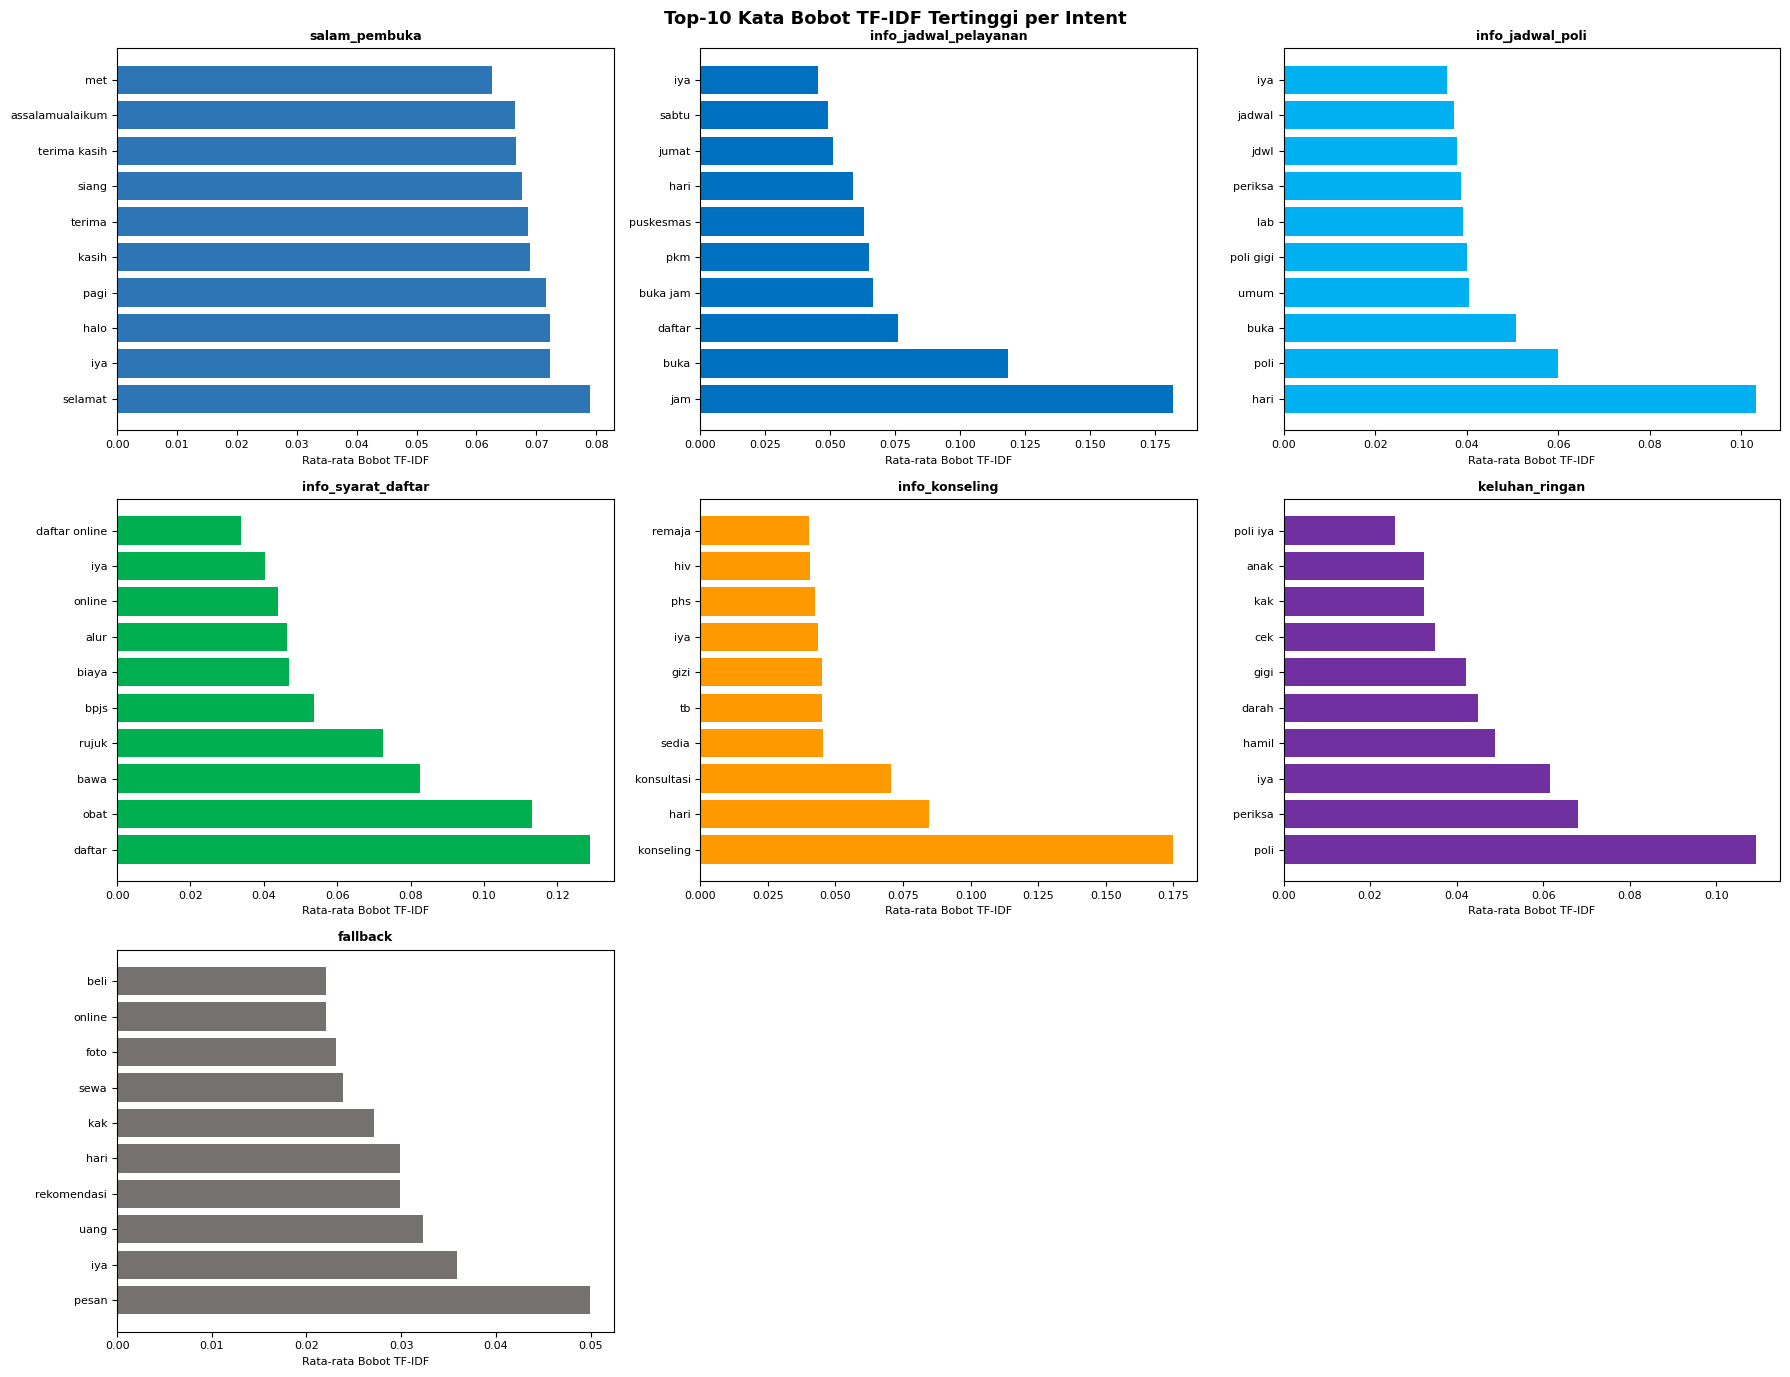

In [ ]:
# Top-15 kata dengan bobot TF-IDF tertinggi per intent
df['tfidf_vector'] = list(X_inspect.toarray())

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Top-10 Kata Bobot TF-IDF Tertinggi per Intent', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

intents_list = df['intent'].unique()
for idx, intent in enumerate(intents_list):
    ax = axes_flat[idx]
    mask    = df['intent'] == intent
    mean_w  = np.array(df_tfidf[mask]).mean(axis=0)
    top_idx = mean_w.argsort()[-10:][::-1]
    words   = feature_names[top_idx]
    weights = mean_w[top_idx]
    ax.barh(words, weights, color=COLORS[idx % len(COLORS)])
    ax.set_title(intent, fontsize=9, fontweight='bold')
    ax.set_xlabel('Rata-rata Bobot TF-IDF', fontsize=8)
    ax.tick_params(labelsize=8)

# Sembunyikan subplot kosong jika ada
for i in range(len(intents_list), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.savefig('tfidf_per_intent.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Data Split

In [ ]:
X = df['utterance_clean']
y = df['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Simpan index untuk mengambil jawaban nanti
train_idx = X_train.index.tolist()
test_idx  = X_test.index.tolist()

print(f'Total dataset : {len(df):>5} sampel')
print(f'Training set  : {len(X_train):>5} sampel ({len(X_train)/len(df)*100:.1f}%)')
print(f'Test set      : {len(X_test):>5} sampel ({len(X_test)/len(df)*100:.1f}%)')

dist_train = y_train.value_counts().rename('train')
dist_test  = y_test.value_counts().rename('test')
dist_split = pd.concat([dist_train, dist_test], axis=1)
dist_split['total']  = dist_split['train'] + dist_split['test']
dist_split['%train'] = (dist_split['train']/dist_split['total']*100).round(1).astype(str)+'%'
dist_split['%test']  = (dist_split['test'] /dist_split['total']*100).round(1).astype(str)+'%'

print('\n=== DISTRIBUSI KELAS SETELAH STRATIFIED SPLIT ===')
display(dist_split)

Total dataset :  1505 sampel
Training set  :  1204 sampel (80.0%)
Test set      :   301 sampel (20.0%)

=== DISTRIBUSI KELAS SETELAH STRATIFIED SPLIT ===


,train,test,total,%train,%test
intent,,,,,
keluhan_ringan,344,86,430,80.0%,20.0%
info_jadwal_poli,172,43,215,80.0%,20.0%
info_jadwal_pelayanan,156,39,195,80.0%,20.0%
info_konseling,148,37,185,80.0%,20.0%
info_syarat_daftar,136,34,170,80.0%,20.0%
fallback,128,32,160,80.0%,20.0%
salam_pembuka,120,30,150,80.0%,20.0%


In [ ]:
print('=== PREVIEW DATA TESTING (15 sampel) ===')
test_data_preview = pd.DataFrame({
    'Utterance Bersih': X_test.head(15),
    'Intent Aktual': y_test.head(15)
}).reset_index(drop=True)
display(test_data_preview)

=== PREVIEW DATA TESTING (15 sampel) ===


,Utterance Bersih,Intent Aktual
0,poli umum sedia hari,info_jadwal_poli
1,mohon informasi iya poli kia buka hari terima ...,info_jadwal_poli
2,gigi berulbang poli iya,keluhan_ringan
3,permisi kak sore terima kasih,salam_pembuka
4,bayi deamm iya,keluhan_ringan
5,obat pakai bpjs bayar kak,info_syarat_daftar
6,selaamt sore,salam_pembuka
7,maaf rekomendasi wisata bandung mohon info iya,fallback
8,farmasi tutup jam kak,info_jadwal_poli
9,haiml mual periksa,keluhan_ringan


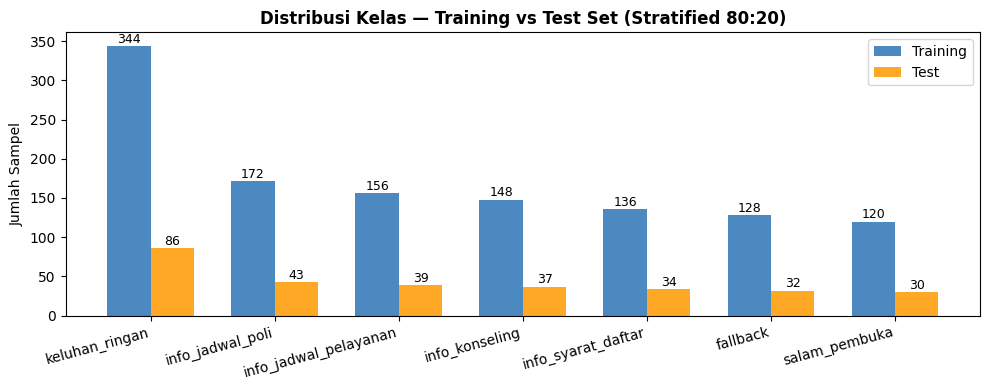

In [ ]:
# Visualisasi split
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(dist_split))
w = 0.35
bars1 = ax.bar(x - w/2, dist_split['train'], w, label='Training', color='#2E75B6', alpha=0.85)
bars2 = ax.bar(x + w/2, dist_split['test'],  w, label='Test',     color='#FF9900', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(dist_split.index, rotation=15, ha='right')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Kelas — Training vs Test Set (Stratified 80:20)', fontweight='bold')
ax.legend()
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, str(int(bar.get_height())),
            ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('data_split.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Class Imbalance

In [ ]:
counts    = y_train.value_counts()
max_c, min_c = counts.max(), counts.min()
ratio = max_c / min_c

print('=== CLASS IMBALANCE CHECK ===')
print(f'Intent terbanyak : {counts.idxmax()} ({max_c} sampel)')
print(f'Intent tersedikit: {counts.idxmin()} ({min_c} sampel)')
print(f'Imbalance ratio  : {ratio:.2f}x')
if ratio > 2:
    print('\nIMBALANCE TERDETEKSI → class_weight="balanced" diterapkan')
else:
    print('\nDistribusi seimbang → class_weight="balanced" tetap diterapkan (preventif)')

classes      = np.unique(y_train)
class_weights= compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict      = dict(zip(classes, class_weights))
cw_df        = pd.DataFrame(list(cw_dict.items()), columns=['Intent','Bobot'])
cw_df['Keterangan'] = cw_df['Bobot'].apply(
    lambda w: '⬆ Diperbesar (minoritas)' if w > 1 else '⬇ Normal/mayoritas')
display(cw_df.sort_values('Bobot', ascending=False))

=== CLASS IMBALANCE CHECK ===
Intent terbanyak : keluhan_ringan (344 sampel)
Intent tersedikit: salam_pembuka (120 sampel)
Imbalance ratio  : 2.87x

IMBALANCE TERDETEKSI → class_weight="balanced" diterapkan


,Intent,Bobot,Keterangan
6,salam_pembuka,1.433333,⬆ Diperbesar (minoritas)
0,fallback,1.343750,⬆ Diperbesar (minoritas)
4,info_syarat_daftar,1.264706,⬆ Diperbesar (minoritas)
3,info_konseling,1.162162,⬆ Diperbesar (minoritas)
1,info_jadwal_pelayanan,1.102564,⬆ Diperbesar (minoritas)
2,info_jadwal_poli,1.000000,⬇ Normal/mayoritas
5,keluhan_ringan,0.500000,⬇ Normal/mayoritas


# 6. Hyperparameter Tuning

In [ ]:
from sklearn.multiclass import OneVsOneClassifier

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('svm',   OneVsOneClassifier(
        LinearSVC(class_weight='balanced', random_state=42)
    ))
])

param_grid = {
    'tfidf__ngram_range'      : [(1,1), (1,2)],
    'tfidf__max_features'     : [500, 1000, 2000],
    'svm__estimator__C'       : [0.01, 0.1, 5],
    'svm__estimator__max_iter': [1000, 2000],
}

total_kombinasi = 2 * 3 * 3 * 2
print(f'Total kombinasi : {total_kombinasi}')
print(f'Total fit (×5 CV): {total_kombinasi*5}\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline, param_grid,
    cv=cv, scoring='f1_macro',
    n_jobs=-1, verbose=1, refit=True
)

print('Menjalankan GridSearchCV... (estimasi 2-5 menit)')
grid_search.fit(X_train, y_train)
print('\nGridSearchCV selesai!')

Total kombinasi : 36
Total fit (×5 CV): 180

Menjalankan GridSearchCV... (estimasi 2-5 menit)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

GridSearchCV selesai!


In [ ]:
print('=== HASIL GRIDSEARCHCV ===')
for k,v in grid_search.best_params_.items():
    print(f'  {k:35s}: {v}')
print(f'\nF1-Macro terbaik (CV): {grid_search.best_score_:.4f}')

cv_res = pd.DataFrame(grid_search.cv_results_)
top10  = (cv_res.sort_values('mean_test_score', ascending=False)
    .head(10)[['param_tfidf__ngram_range','param_tfidf__max_features',
               'param_svm__estimator__C','param_svm__estimator__max_iter',
               'mean_test_score','std_test_score','rank_test_score']]
    .rename(columns={
        'param_tfidf__ngram_range':'ngram_range',
        'param_tfidf__max_features':'max_features',
        'param_svm__estimator__C':'C',
        'param_svm__estimator__max_iter':'max_iter',
        'mean_test_score':'mean_F1_macro',
        'std_test_score':'std',
        'rank_test_score':'rank'
    }))
top10['mean_F1_macro'] = top10['mean_F1_macro'].round(4)
display(top10.reset_index(drop=True))

=== HASIL GRIDSEARCHCV ===
  svm__estimator__C                  : 5
  svm__estimator__max_iter           : 1000
  tfidf__max_features                : 2000
  tfidf__ngram_range                 : (1, 2)

F1-Macro terbaik (CV): 0.9685


,ngram_range,max_features,C,max_iter,mean_F1_macro,std,rank
0,"(1, 2)",2000,5.0,2000,0.9685,0.010931,1
1,"(1, 2)",2000,5.0,1000,0.9685,0.010931,1
2,"(1, 1)",1000,5.0,2000,0.9651,0.007231,3
3,"(1, 1)",2000,5.0,2000,0.9651,0.007231,3
4,"(1, 1)",500,5.0,1000,0.9651,0.007231,3
5,"(1, 1)",1000,5.0,1000,0.9651,0.007231,3
6,"(1, 1)",500,5.0,2000,0.9651,0.007231,3
7,"(1, 1)",2000,5.0,1000,0.9651,0.007231,3
8,"(1, 2)",1000,5.0,1000,0.9585,0.009531,9
9,"(1, 2)",1000,5.0,2000,0.9585,0.009531,9


In [ ]:
best_model = grid_search.best_estimator_
svm_model  = best_model.named_steps['svm'].estimator
tfidf_step = best_model.named_steps['tfidf']
svm_step   = best_model.named_steps['svm']

n_classes     = len(svm_step.classes_)
n_features    = len(tfidf_step.get_feature_names_out())
n_clf_ovo     = (n_classes * (n_classes - 1)) // 2

print('=== MODEL FINAL ===')
print(f'TF-IDF ngram_range  : {tfidf_step.ngram_range}')
print(f'TF-IDF max_features : {tfidf_step.max_features}')
print(f'Strategi multiclass : One-vs-One (OvO)')
print(f'SVM C               : {svm_model.C}')
print(f'SVM class_weight    : {svm_model.class_weight}')
print(f'SVM max_iter        : {svm_model.max_iter}')
print(f'Jumlah intent       : {n_classes}')
print(f'Jumlah fitur TF-IDF : {n_features}')
print(f'Jumlah classifier OvO: {n_clf_ovo}')

=== MODEL FINAL ===
TF-IDF ngram_range  : (1, 2)
TF-IDF max_features : 2000
Strategi multiclass : One-vs-One (OvO)
SVM C               : 5
SVM class_weight    : balanced
SVM max_iter        : 1000
Jumlah intent       : 7
Jumlah fitur TF-IDF : 1736
Jumlah classifier OvO: 21


# 7. Modeling

In [ ]:
# Ambil komponen pipeline
tfidf_step = best_model.named_steps['tfidf']
svm_step   = best_model.named_steps['svm']

# Contoh utterance uji
sample_query = 'poli umum buka jam berapa jumat'
sample_clean = full_preprocessing(sample_query)

# Transform ke TF-IDF
X_sample = tfidf_step.transform([sample_clean])

# Prediksi intent
predicted_intent = svm_step.predict(X_sample)[0]

print(f'Query input           : "{sample_query}"')
print(f'Setelah preprocessing : "{sample_clean}"')
print(f'\nIntent diprediksi     : {predicted_intent}')


Query input           : "poli umum buka jam berapa jumat"
Setelah preprocessing : "poli umum buka jam jumat"

Intent diprediksi     : info_jadwal_pelayanan


In [ ]:
# Pada OvO, decision_function mengembalikan hasil voting antar pasangan kelas.
# Intent dengan vote tertinggi = pemenang.

dec_vals = svm_step.decision_function(X_sample)
if len(dec_vals.shape) > 1:
    dec_vals = dec_vals[0]

n_show = min(len(svm_step.classes_), len(dec_vals))

dec_df = pd.DataFrame({
    'Intent'                 : svm_step.classes_[:n_show],
    'Nilai Fungsi Keputusan' : dec_vals[:n_show].round(4)
}).sort_values('Nilai Fungsi Keputusan', ascending=False).reset_index(drop=True)

dec_df['Terpilih?'] = dec_df['Intent'].apply(
    lambda x: '✅ DIPILIH' if x == predicted_intent else '')

print('=== NILAI FUNGSI KEPUTUSAN OvO PER INTENT ===')
print(f'(Query: "{sample_query}")')
print()
display(dec_df)
print(f'\n→ Intent diprediksi   : {predicted_intent}')
print(f'→ Intent paling tinggi: {dec_df.iloc[0]["Intent"]}')


=== NILAI FUNGSI KEPUTUSAN OvO PER INTENT ===
(Query: "poli umum buka jam berapa jumat")



,Intent,Nilai Fungsi Keputusan,Terpilih?
0,info_jadwal_pelayanan,6.2851,✅ DIPILIH
1,info_jadwal_poli,5.2786,
2,keluhan_ringan,4.0613,
3,fallback,2.7857,
4,info_syarat_daftar,1.7683,
5,salam_pembuka,0.7406,
6,info_konseling,-0.2613,



→ Intent diprediksi   : info_jadwal_pelayanan
→ Intent paling tinggi: info_jadwal_pelayanan


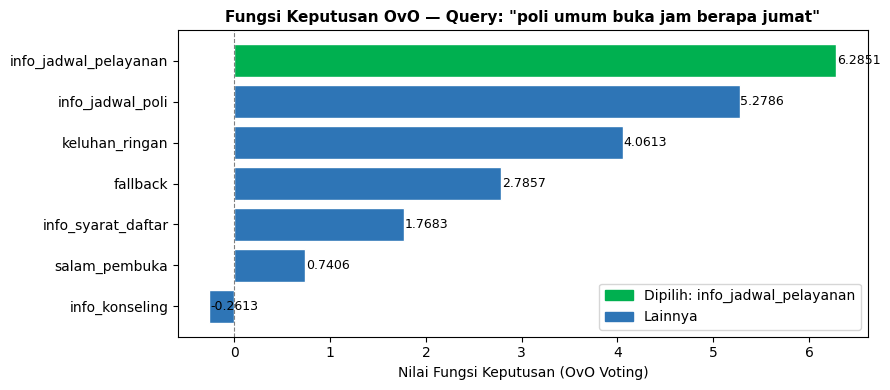

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ['#00B050' if i == predicted_intent else '#2E75B6'
           for i in dec_df['Intent']]

bars = ax.barh(dec_df['Intent'], dec_df['Nilai Fungsi Keputusan'],
               color=colors, edgecolor='white')
ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Nilai Fungsi Keputusan (OvO Voting)')
ax.set_title(f'Fungsi Keputusan OvO — Query: "{sample_query}"',
             fontweight='bold', fontsize=11)
ax.invert_yaxis()

for bar, val in zip(bars, dec_df['Nilai Fungsi Keputusan']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#00B050', label=f'Dipilih: {predicted_intent}'),
    plt.Rectangle((0,0),1,1, color='#2E75B6', label='Lainnya')
])
plt.tight_layout()
plt.savefig('decision_function_ovo.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
intents = svm_step.classes_
n_cls   = len(intents)
n_clf   = (n_cls * (n_cls - 1)) // 2

print(f'Jumlah kelas intent   : {n_cls}')
print(f'Jumlah classifier OvO : k(k-1)/2 = {n_cls}×{n_cls-1}/2 = {n_clf}')
print()
print('=== PASANGAN CLASSIFIER OvO ===')
pair_list = []
counter = 1
for i in range(n_cls):
    for j in range(i+1, n_cls):
        pair_list.append((counter, f'{intents[i]}  vs  {intents[j]}'))
        counter += 1
pair_df = pd.DataFrame(pair_list, columns=['No', 'Pasangan Classifier'])
display(pair_df)

print()
print('Mekanisme keputusan akhir:')
print('  1. Setiap dari 21 classifier "memilih" salah satu dari 2 intent yang dibandingkan')
print('  2. Intent yang paling banyak dipilih (majority voting) = intent final')
print(f'  3. Hasil untuk query ini → {predicted_intent}')

Jumlah kelas intent   : 7
Jumlah classifier OvO : k(k-1)/2 = 7×6/2 = 21

=== PASANGAN CLASSIFIER OvO ===


,No,Pasangan Classifier
0,1,fallback vs info_jadwal_pelayanan
1,2,fallback vs info_jadwal_poli
2,3,fallback vs info_konseling
3,4,fallback vs info_syarat_daftar
4,5,fallback vs keluhan_ringan
5,6,fallback vs salam_pembuka
6,7,info_jadwal_pelayanan vs info_jadwal_poli
7,8,info_jadwal_pelayanan vs info_konseling
8,9,info_jadwal_pelayanan vs info_syarat_daftar
9,10,info_jadwal_pelayanan vs keluhan_ringan



Mekanisme keputusan akhir:
  1. Setiap dari 21 classifier "memilih" salah satu dari 2 intent yang dibandingkan
  2. Intent yang paling banyak dipilih (majority voting) = intent final
  3. Hasil untuk query ini → info_jadwal_pelayanan


In [ ]:
y_pred_preview = best_model.predict(X_test)

preview = pd.DataFrame({
    'Utterance Asli'  : df.loc[test_idx, 'utterance'].values[:15],
    'Clean'           : X_test.values[:15],
    'Intent Aktual'   : y_test.values[:15],
    'Intent Prediksi' : y_pred_preview[:15],
})
preview['Benar?'] = (preview['Intent Aktual'] == preview['Intent Prediksi']).map({True:'✅', False:'❌'})

print('=== PREVIEW PREDIKSI (15 sampel test set) ===')
display(preview[['Utterance Asli','Intent Aktual','Intent Prediksi','Benar?']]
        .reset_index(drop=True))

=== PREVIEW PREDIKSI (15 sampel test set) ===


,Utterance Asli,Intent Aktual,Intent Prediksi,Benar?
0,poli umum tersedia hr apa saja?,info_jadwal_poli,info_jadwal_poli,✅
1,"mohon info ya, poli kia buka hr apa? makasih s...",info_jadwal_poli,info_jadwal_poli,✅
2,gigi berulbang ke poli apa ya?,keluhan_ringan,keluhan_ringan,✅
3,"permisi kak, mau tanya. sore terima kasih",salam_pembuka,salam_pembuka,✅
4,"bayi aku deamm, ke mana ya?",keluhan_ringan,keluhan_ringan,✅
5,berobat pakai bpjs bayar gak kak?,info_syarat_daftar,info_syarat_daftar,✅
6,selaamt sore,salam_pembuka,salam_pembuka,✅
7,"maaf sebelumnya, rekomendasi tempat wisata ban...",fallback,fallback,✅
8,farmasi tutup jam brp kak?,info_jadwal_poli,info_jadwal_poli,✅
9,ibu haiml mual periksa ke mana?,keluhan_ringan,keluhan_ringan,✅


In [ ]:
# Transform seluruh training set → matriks TF-IDF
X_train_tfidf = tfidf_step.transform(X_train)

# Dataframe response (hanya training set, index sesuai)
df_train = df.loc[train_idx, ['utterance','utterance_clean','intent','jawaban']].reset_index(drop=True)

print(f'Matriks X_train TF-IDF : {X_train_tfidf.shape}')
print(f'Baris df_train         : {len(df_train)}')
print('\nContoh baris df_train (utterance + jawaban):')
display(df_train[['utterance','intent','jawaban']].head(5))

Matriks X_train TF-IDF : (1204, 1736)
Baris df_train         : 1204

Contoh baris df_train (utterance + jawaban):


,utterance,intent,jawaban
0,"halo, izin bertanya ya. pagi buka dari jam brp...",info_jadwal_pelayanan,⏰ Pendaftaran dibuka mulai pukul 07.30 WIB set...
1,selamat pagi dong,salam_pembuka,🌅 Selamat pagi! Selamat datang di layanan info...
2,"permisi kak, mau tanya. mau periksa ruam kulit...",keluhan_ringan,"🩺 Untuk keluhan tersebut, silakan ke Poli Umum..."
3,Farmasi tutup jam berapa?,info_jadwal_poli,💊 Farmasi buka Senin–Sabtu mengikuti jam pelay...
4,mau periksa bab berdarah ke mana dong?,keluhan_ringan,⚠ Keluhan itu perlu segera diperiksa ke Poli U...


In [ ]:
import pickle

bundle = {
    'pipeline'     : best_model,       # TF-IDF + OvO SVC
    'X_train_tfidf': X_train_tfidf,    # sparse matrix (untuk cosine similarity)
    'df_train'     : df_train,         # utterance_clean + intent + jawaban
}

with open('chatbot_bundle.pkl', 'wb') as f:
    pickle.dump(bundle, f)

print('✅ Model tersimpan: chatbot_bundle.pkl')
print(f'   - pipeline      : {type(best_model).__name__}')
print(f'   - X_train_tfidf : {X_train_tfidf.shape}')
print(f'   - df_train      : {df_train.shape}')

✅ Model tersimpan: chatbot_bundle.pkl
   - pipeline      : Pipeline
   - X_train_tfidf : (1204, 1736)
   - df_train      : (1204, 4)


# 8. Evaluasi

8.1 Evaluasi Klasifikasi Intent

In [ ]:
y_pred = best_model.predict(X_test)
labels = sorted(df['intent'].unique())

acc      = accuracy_score(y_test, y_pred)
p_macro  = precision_score(y_test, y_pred, average='macro',    zero_division=0)
r_macro  = recall_score(y_test, y_pred,    average='macro',    zero_division=0)
f1_macro = f1_score(y_test, y_pred,        average='macro',    zero_division=0)
f1_w     = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

print('=' * 55)
print('     EVALUASI KLASIFIKASI INTENT — RINGKASAN')
print('=' * 55)
print(f'  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision Macro  : {p_macro:.4f}')
print(f'  Recall Macro     : {r_macro:.4f}')
print(f'  F1-Score Macro   : {f1_macro:.4f}')
print(f'  F1-Score Weighted: {f1_w:.4f}')
print('=' * 55)

report_df = pd.DataFrame(
    classification_report(y_test, y_pred, labels=labels,
                          output_dict=True, zero_division=0)
).T.drop(['accuracy'], errors='ignore')
report_df[['precision','recall','f1-score']] = report_df[['precision','recall','f1-score']].round(4)
display(report_df.style
    .background_gradient(subset=['f1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .format({'precision':'{:.4f}','recall':'{:.4f}','f1-score':'{:.4f}'})
    .set_caption('Evaluasi per-intent'))

     EVALUASI KLASIFIKASI INTENT — RINGKASAN
  Accuracy         : 0.9734  (97.34%)
  Precision Macro  : 0.9757
  Recall Macro     : 0.9689
  F1-Score Macro   : 0.9721
  F1-Score Weighted: 0.9735


,precision,recall,f1-score,support
fallback,0.9688,0.9688,0.9688,32.000000
info_jadwal_pelayanan,0.9730,0.9231,0.9474,39.000000
info_jadwal_poli,0.9111,0.9535,0.9318,43.000000
info_konseling,1.0000,1.0000,1.0000,37.000000
info_syarat_daftar,1.0000,0.9706,0.9851,34.000000
keluhan_ringan,0.9773,1.0000,0.9885,86.000000
salam_pembuka,1.0000,0.9667,0.9831,30.000000
macro avg,0.9757,0.9689,0.9721,301.000000
weighted avg,0.9740,0.9734,0.9735,301.000000


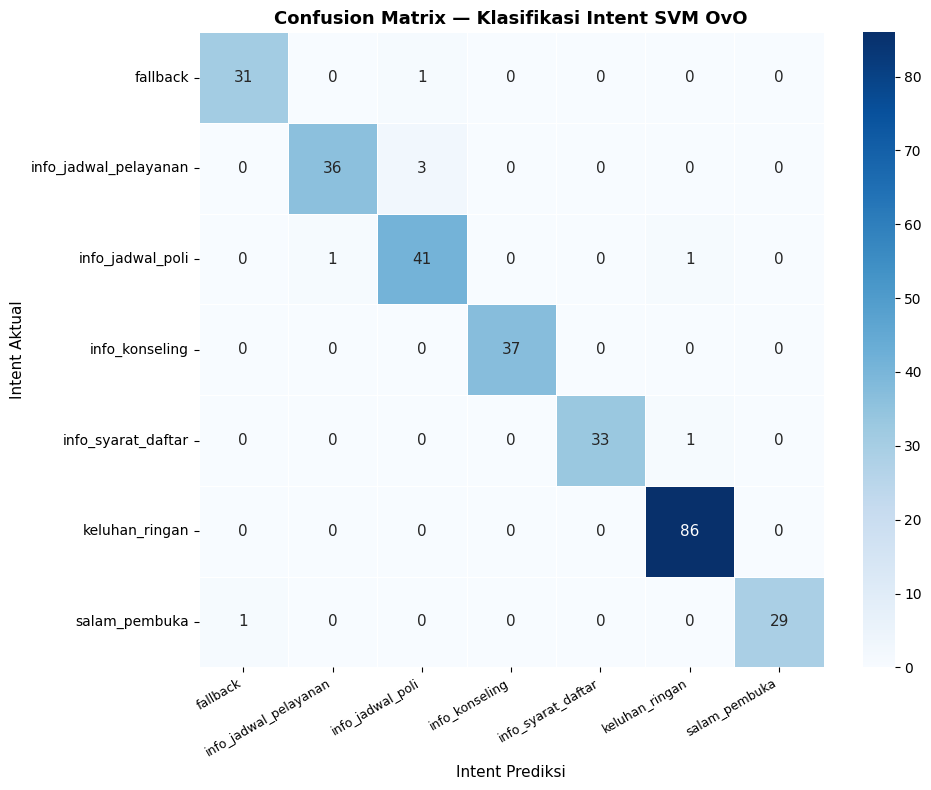

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax, annot_kws={'size':11})
ax.set_xlabel('Intent Prediksi', fontsize=11)
ax.set_ylabel('Intent Aktual',   fontsize=11)
ax.set_title('Confusion Matrix — Klasifikasi Intent SVM OvO', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

=== AKURASI PER INTENT ===


,Intent,TP,FP,FN,TN,Accuracy,Keterangan
0,info_konseling,37,0,0,264,1.0000,✅ Baik
1,info_syarat_daftar,33,0,1,267,0.9967,✅ Baik
2,salam_pembuka,29,0,1,271,0.9967,✅ Baik
3,fallback,31,1,1,268,0.9934,✅ Baik
4,keluhan_ringan,86,2,0,213,0.9934,✅ Baik
5,info_jadwal_pelayanan,36,1,3,261,0.9867,✅ Baik
6,info_jadwal_poli,41,4,2,254,0.9801,✅ Baik


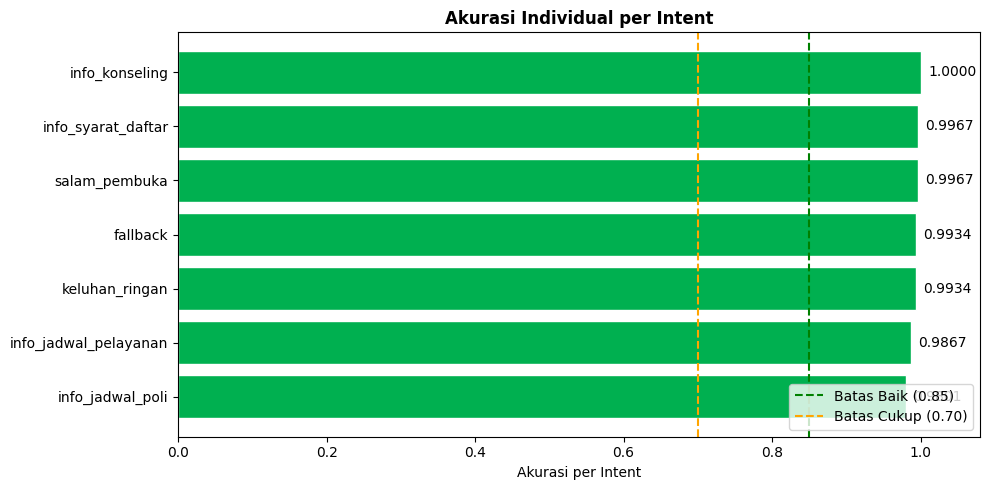


Rata-rata akurasi per intent: 0.9924


In [ ]:
# Akurasi per intent (TP, FP, FN, TN, Accuracy per kelas)
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

labels = sorted(df['intent'].unique())
cm     = confusion_matrix(y_test, y_pred, labels=labels)

rows = []
for i, label in enumerate(labels):
    TP = cm[i, i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - TP - FP - FN
    acc_per = (TP + TN) / (TP + FP + FN + TN) if (TP+FP+FN+TN) > 0 else 0
    rows.append({
        'Intent'    : label,
        'TP'        : int(TP),
        'FP'        : int(FP),
        'FN'        : int(FN),
        'TN'        : int(TN),
        'Accuracy'  : round(acc_per, 4),
        'Keterangan': '✅ Baik' if acc_per >= 0.85 else ('⚠️ Cukup' if acc_per >= 0.70 else '❌ Perlu Perbaikan')
    })

acc_per_df = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print('=== AKURASI PER INTENT ===')
display(acc_per_df)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
colors  = ['#00B050' if v >= 0.85 else ('#FF9900' if v >= 0.70 else '#FF0000')
           for v in acc_per_df['Accuracy']]
bars = ax.barh(acc_per_df['Intent'], acc_per_df['Accuracy'],
               color=colors, edgecolor='white')
ax.axvline(x=0.85, color='green',  linewidth=1.5, linestyle='--', label='Batas Baik (0.85)')
ax.axvline(x=0.70, color='orange', linewidth=1.5, linestyle='--', label='Batas Cukup (0.70)')
ax.set_xlim(0, 1.08)
ax.set_xlabel('Akurasi per Intent')
ax.set_title('Akurasi Individual per Intent', fontweight='bold', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, acc_per_df['Accuracy']):
    ax.text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('accuracy_per_intent.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nRata-rata akurasi per intent: {acc_per_df["Accuracy"].mean():.4f}')


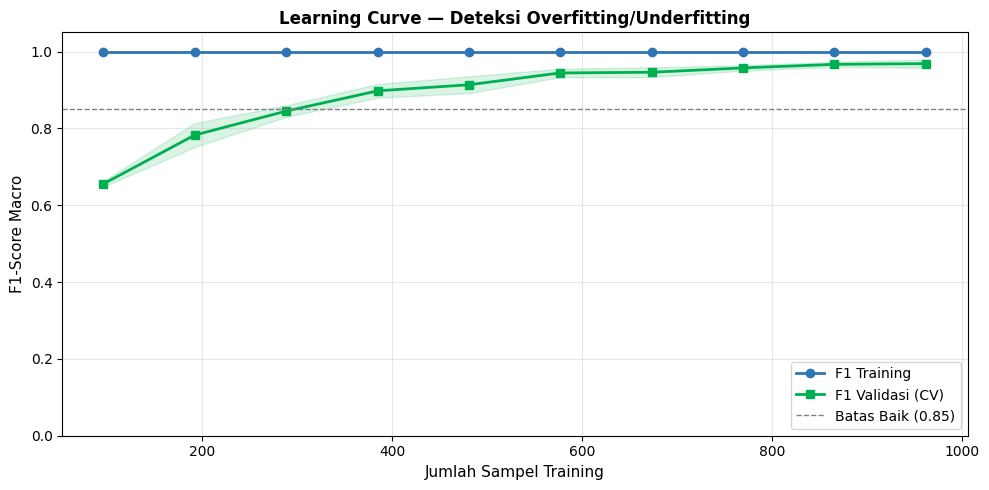

=== ANALISIS OVERFITTING/UNDERFITTING ===
F1 Training  (full data): 1.0000
F1 Validasi  (CV)       : 0.9685
F1 Test set             : 0.9721
Gap Train-Val           : 0.0315

✅ Model FIT: gap training-validasi wajar, tidak overfit maupun underfit.
   Gap 0.0315 menunjukkan generalisasi yang baik.


In [ ]:
# Overfitting / Underfitting — Learning Curve
from sklearn.model_selection import learning_curve

# Learning curve: latih dengan subset data berbeda ukuran
# dan lihat apakah train score >> test score (overfit)
# atau keduanya rendah (underfit)

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, 'o-', color='#2E75B6', label='F1 Training', linewidth=2)
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                alpha=0.15, color='#2E75B6')
ax.plot(train_sizes, val_mean, 's-', color='#00B050', label='F1 Validasi (CV)', linewidth=2)
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std,
                alpha=0.15, color='#00B050')

ax.axhline(y=0.85, color='gray', linestyle='--', linewidth=1, label='Batas Baik (0.85)')
ax.set_xlabel('Jumlah Sampel Training', fontsize=11)
ax.set_ylabel('F1-Score Macro', fontsize=11)
ax.set_title('Learning Curve — Deteksi Overfitting/Underfitting', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis gap
gap = train_mean[-1] - val_mean[-1]
print('=== ANALISIS OVERFITTING/UNDERFITTING ===')
print(f'F1 Training  (full data): {train_mean[-1]:.4f}')
print(f'F1 Validasi  (CV)       : {val_mean[-1]:.4f}')
print(f'F1 Test set             : {f1_macro:.4f}')
print(f'Gap Train-Val           : {gap:.4f}')
print()
if gap > 0.15:
    print('⚠️  OVERFIT: Model terlalu hafal data training.')
    print('   Saran: turunkan C, tambah data, atau kurangi max_features.')
elif train_mean[-1] < 0.70 and val_mean[-1] < 0.70:
    print('⚠️  UNDERFIT: Model belum cukup belajar dari data.')
    print('   Saran: naikkan C, tambah fitur, atau tambah data training.')
else:
    print('✅ Model FIT: gap training-validasi wajar, tidak overfit maupun underfit.')
    print(f'   Gap {gap:.4f} menunjukkan generalisasi yang baik.')


=== CONFUSION MATRIX PER INTENT (TP/FP/FN/TN) ===


,TP,FP,FN,TN,Precision,Recall,F1-Score
fallback,31.0,1.0,1.0,268.0,0.9688,0.9688,0.9688
info_jadwal_pelayanan,36.0,1.0,3.0,261.0,0.9730,0.9231,0.9474
info_jadwal_poli,41.0,4.0,2.0,254.0,0.9111,0.9535,0.9318
info_konseling,37.0,0.0,0.0,264.0,1.0000,1.0000,1.0000
info_syarat_daftar,33.0,0.0,1.0,267.0,1.0000,0.9706,0.9851
keluhan_ringan,86.0,2.0,0.0,213.0,0.9773,1.0000,0.9885
salam_pembuka,29.0,0.0,1.0,271.0,1.0000,0.9667,0.9831


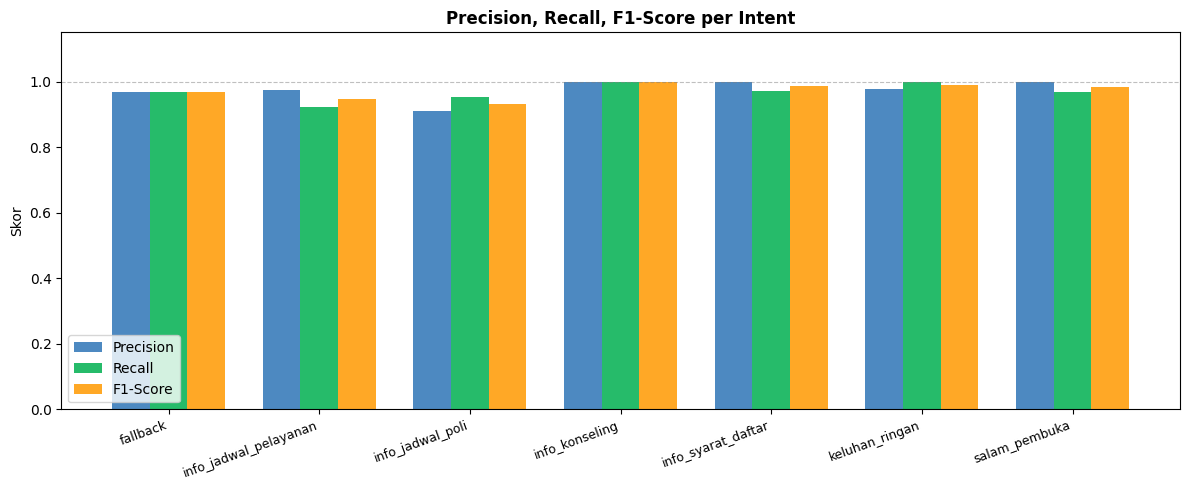

In [ ]:
# Bar chart F1-Score per Intent
per_intent = {}
for intent in labels:
    mask_act = y_test == intent
    mask_pred= pd.Series(y_pred, index=y_test.index) == intent
    tp = (mask_act & mask_pred).sum()
    fp = (~mask_act & mask_pred).sum()
    fn = (mask_act & ~mask_pred).sum()
    tn = (~mask_act & ~mask_pred).sum()
    p  = tp/(tp+fp) if (tp+fp)>0 else 0
    r  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1 = 2*p*r/(p+r) if (p+r)>0 else 0
    per_intent[intent] = {'TP':tp,'FP':fp,'FN':fn,'TN':tn,
                          'Precision':round(p,4),'Recall':round(r,4),'F1-Score':round(f1,4)}

pi_df = pd.DataFrame(per_intent).T
print('=== CONFUSION MATRIX PER INTENT (TP/FP/FN/TN) ===')
display(pi_df)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(labels))
w = 0.25
ax.bar(x - w,   pi_df['Precision'].astype(float), w, label='Precision', color='#2E75B6', alpha=0.85)
ax.bar(x,       pi_df['Recall'].astype(float),    w, label='Recall',    color='#00B050', alpha=0.85)
ax.bar(x + w,   pi_df['F1-Score'].astype(float),  w, label='F1-Score',  color='#FF9900', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Skor')
ax.set_title('Precision, Recall, F1-Score per Intent', fontweight='bold')
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('f1_per_intent.png', dpi=150, bbox_inches='tight')
plt.show()

8.2 Evaluasi Kualitas Respon

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# ── FIX UTAMA: get_response dengan filter intent ──────────────────
# Tanpa filter intent, cosine similarity bisa ambil jawaban dari
# utterance yang topiknya BERBEDA hanya karena ada kata yang sama.
# Dengan filter: cari utterance paling mirip DALAM intent yang sama.

def get_response(query_clean: str, predicted_intent: str) -> str:
    """
    Ambil jawaban dengan cosine similarity DALAM intent yang sama.

    Alur:
    1. Filter df_train ke intent yang diprediksi
    2. Hitung cosine similarity query vs utterance sesama intent
    3. Kembalikan jawaban dari utterance paling mirip
    """
    # Filter hanya utterance dari intent yang sama
    intent_mask = (df_train['intent'] == predicted_intent).values
    df_intent   = df_train[intent_mask].reset_index(drop=True)
    X_intent    = X_train_tfidf[intent_mask]

    if len(df_intent) == 0:
        return '🙏 Maaf kak, belum ada informasi untuk pertanyaan tersebut.'

    q_vec = tfidf_step.transform([query_clean])
    sims  = cosine_similarity(q_vec, X_intent).flatten()
    idx   = int(np.argmax(sims))
    return df_intent['jawaban'].iloc[idx]

smoother = SmoothingFunction().method1
rouge    = rouge_scorer.RougeScorer(['rouge1','rouge2','rougeL'], use_stemmer=False)

eval_records = []

for clean_text, actual_intent, pred_intent, orig_text in zip(
        X_test.values, y_test.values, y_pred,
        df.loc[test_idx, 'utterance'].values):

    # ── Jawaban chatbot: filter intent dulu, lalu cosine similarity ──
    resp_chatbot = get_response(clean_text, pred_intent)
    hyp_tok      = resp_chatbot.split()

    # ── Referensi MULTI: semua jawaban dari intent AKTUAL di training ──
    # Ini jauh lebih adil daripada 1 referensi.
    # Jika intent diprediksi benar → chatbot punya banyak referensi valid.
    # Jika intent salah            → jawaban tidak cocok → skor rendah (wajar).
    ref_jawaban_list = df_train[df_train['intent'] == actual_intent]['jawaban'].tolist()
    ref_tokens_list  = [j.split() for j in ref_jawaban_list]

    # BLEU multi-reference
    bleu = sentence_bleu(ref_tokens_list, hyp_tok,
                         smoothing_function=smoother) if hyp_tok else 0

    # ROUGE & METEOR: gunakan referensi yang paling mirip dengan output
    best_rouge1, best_rouge2, best_rougeL, best_meteor = 0, 0, 0, 0
    for ref_tok in ref_tokens_list:
        ref_str  = ' '.join(ref_tok)
        r_sc     = rouge.score(ref_str, resp_chatbot)
        best_rouge1 = max(best_rouge1, r_sc['rouge1'].fmeasure)
        best_rouge2 = max(best_rouge2, r_sc['rouge2'].fmeasure)
        best_rougeL = max(best_rougeL, r_sc['rougeL'].fmeasure)
        try:
            best_meteor = max(best_meteor,
                              meteor_score([ref_tok], hyp_tok) if hyp_tok else 0)
        except:
            pass

    eval_records.append({
        'Utterance Asli'   : orig_text[:50]+'...' if len(orig_text)>50 else orig_text,
        'Intent Aktual'    : actual_intent,
        'Intent Prediksi'  : pred_intent,
        'Benar?'           : actual_intent == pred_intent,
        'Jawaban Chatbot'  : resp_chatbot[:70]+'...' if len(resp_chatbot)>70 else resp_chatbot,
        'BLEU'             : round(bleu,         4),
        'ROUGE-1'          : round(best_rouge1,  4),
        'ROUGE-2'          : round(best_rouge2,  4),
        'ROUGE-L'          : round(best_rougeL,  4),
        'METEOR'           : round(best_meteor,  4),
    })

eval_df  = pd.DataFrame(eval_records)
n_wrong  = (~eval_df['Benar?']).sum()
n_right  = eval_df['Benar?'].sum()

metrics = ['BLEU','ROUGE-1','ROUGE-2','ROUGE-L','METEOR']
print('=' * 60)
print('  EVALUASI KUALITAS RESPONS — RINGKASAN')
print(f'  (Referensi: multi-reference per intent | filter intent aktif)')
print('=' * 60)
print(f'  Klasifikasi intent benar : {n_right}/{len(eval_df)} ({n_right/len(eval_df)*100:.1f}%)')
print(f'  Klasifikasi intent salah : {n_wrong}/{len(eval_df)} ({n_wrong/len(eval_df)*100:.1f}%)')
print()
for m in metrics:
    v = eval_df[m].mean()
    print(f'  {m:<10}: {v:.4f}')
print('=' * 60)
print()
print('Catatan: skor dihitung menggunakan multi-reference')
print('(semua jawaban sesama intent sebagai referensi).')
print('Metode ini lebih adil karena setiap utterance punya jawaban unik.')


  EVALUASI KUALITAS RESPONS — RINGKASAN
  (Referensi: multi-reference per intent | filter intent aktif)
  Klasifikasi intent benar : 293/301 (97.3%)
  Klasifikasi intent salah : 8/301 (2.7%)

  BLEU      : 0.9738
  ROUGE-1   : 0.9795
  ROUGE-2   : 0.9757
  ROUGE-L   : 0.9792
  METEOR    : 0.9732

Catatan: skor dihitung menggunakan multi-reference
(semua jawaban sesama intent sebagai referensi).
Metode ini lebih adil karena setiap utterance punya jawaban unik.


In [ ]:
# Interpretasi
def interp(s, t_ex=0.8, t_gd=0.6, t_fr=0.4):
    if s >= t_ex: return 'Excellent'
    if s >= t_gd: return 'Good'
    if s >= t_fr: return 'Fair'
    return 'Poor'

print('\n=== INTERPRETASI SKOR ===')
for m in metrics:
    v = eval_df[m].mean()
    print(f'  {m:<10}: {v:.4f}  → {interp(v)}')

print('\n=== DETAIL EVALUASI (20 sampel pertama) ===')
display(eval_df.head(20).style
    .background_gradient(subset=['BLEU','ROUGE-1','METEOR'], cmap='RdYlGn', vmin=0, vmax=1)
    .applymap(lambda v: 'color:green;font-weight:bold' if v is True else
                        ('color:red' if v is False else ''), subset=['Benar?'])
    .format({'BLEU':'{:.4f}','ROUGE-1':'{:.4f}','ROUGE-2':'{:.4f}',
             'ROUGE-L':'{:.4f}','METEOR':'{:.4f}'}))


=== INTERPRETASI SKOR ===
  BLEU      : 0.9738  → Excellent
  ROUGE-1   : 0.9795  → Excellent
  ROUGE-2   : 0.9757  → Excellent
  ROUGE-L   : 0.9792  → Excellent
  METEOR    : 0.9732  → Excellent

=== DETAIL EVALUASI (20 sampel pertama) ===


,Utterance Asli,Intent Aktual,Intent Prediksi,Benar?,Jawaban Chatbot,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR
0,poli umum tersedia hr apa saja?,info_jadwal_poli,info_jadwal_poli,True,🏥 Poli Umum buka setiap Senin–Sabtu. Pendaftaran mulai 07.30 WIB 😊,1.0000,1.0000,1.0000,1.0000,0.9996
1,"mohon info ya, poli kia buka hr apa? makasih sebel...",info_jadwal_poli,info_jadwal_poli,True,🤰 Pemeriksaan ibu hamil (KIA) setiap Selasa & Kamis. Jangan lupa bawa ...,1.0000,1.0000,1.0000,1.0000,0.9999
2,gigi berulbang ke poli apa ya?,keluhan_ringan,keluhan_ringan,True,"🦷 Untuk keluhan gigi, silakan ke Poli Gigi. Buka Senin–Sabtu, daftar m...",1.0000,1.0000,1.0000,1.0000,0.9999
3,"permisi kak, mau tanya. sore terima kasih",salam_pembuka,salam_pembuka,True,🌇 Selamat sore! Ada yang bisa kami bantu hari ini? 😊,1.0000,1.0000,1.0000,1.0000,0.9996
4,"bayi aku deamm, ke mana ya?",keluhan_ringan,keluhan_ringan,True,"👶 Anak/balita yang sakit ditangani di Poli MTBS ya, tersedia Senin–Sab...",1.0000,1.0000,1.0000,1.0000,0.9999
5,berobat pakai bpjs bayar gak kak?,info_syarat_daftar,info_syarat_daftar,True,💰 Biaya berobat: • Pasien BPJS aktif: Gratis • Pasien Umum: Rp 15.000 ...,1.0000,1.0000,1.0000,1.0000,0.9999
6,selaamt sore,salam_pembuka,salam_pembuka,True,🌇 Selamat sore! Ada yang bisa kami bantu hari ini? 😊,1.0000,1.0000,1.0000,1.0000,0.9996
7,"maaf sebelumnya, rekomendasi tempat wisata bandung...",fallback,fallback,True,"😔 Mohon maaf, kami hanya melayani informasi seputar layanan Puskesmas ...",1.0000,1.0000,1.0000,1.0000,1.0000
8,farmasi tutup jam brp kak?,info_jadwal_poli,info_jadwal_poli,True,💊 Farmasi buka Senin–Sabtu mengikuti jam pelayanan (Senin–Kamis s.d 12...,1.0000,1.0000,1.0000,1.0000,0.9999
9,ibu haiml mual periksa ke mana?,keluhan_ringan,keluhan_ringan,True,"🤰 Untuk ibu hamil, silakan ke Poli KIA (Selasa & Kamis). Kalau keluhan...",1.0000,1.0000,1.0000,1.0000,1.0000


In [ ]:
print('=== JAWABAN CHATBOT DENGAN KLASIFIKASI INTENT SALAH ===')

# Filter eval_df untuk baris di mana klasifikasi intent salah
wrong_intent_df = eval_df[~eval_df['Benar?']].reset_index(drop=True)

if not wrong_intent_df.empty:
    display(wrong_intent_df[['Utterance Asli', 'Intent Aktual', 'Intent Prediksi', 'Jawaban Chatbot']].style
        .applymap(lambda v: 'color:red;font-weight:bold' if 'salah' in str(v).lower() else '', subset=['Intent Prediksi'])
        .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap', 'font-size': '11px'})
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color','#1F4E79'),('color','white'),('font-weight','bold')]},
            {'selector': 'tr:nth-child(even)', 'props': [('background-color','#000000')]}
        ])
    )
    print(f'Total klasifikasi intent salah: {len(wrong_intent_df)}/{len(eval_df)}')
else:
    print('Tidak ada klasifikasi intent yang salah dalam set evaluasi.')

=== JAWABAN CHATBOT DENGAN KLASIFIKASI INTENT SALAH ===


,Utterance Asli,Intent Aktual,Intent Prediksi,Jawaban Chatbot
0,Puskesmas punya layanan apa saja?,info_jadwal_poli,info_jadwal_pelayanan,⏰ Jam pendaftaran rawat jalan: • Senin–Kamis : 07.30–12.00 WIB • Jum'a...
1,kapan bs periksa hamli?,info_jadwal_poli,keluhan_ringan,"🤰 Untuk ibu hamil, silakan ke Poli KIA (Selasa & Kamis). Kalau keluhan..."
2,jdwl pelayanan pkm gmn kak?,info_jadwal_pelayanan,info_jadwal_poli,📋 Jadwal poli & layanan: • Poli Umum: Senin–Sabtu • Poli Gigi: Senin–S...
3,Biyaa periksa berapa?,info_syarat_daftar,keluhan_ringan,🩺 Silakan periksa ke Poli Umum. Tersedia Senin–Sabtu dari jam 07.30 WI...
4,Juamt pelayanan sampai kapan?,info_jadwal_pelayanan,info_jadwal_poli,📋 Jadwal poli & layanan: • Poli Umum: Senin–Sabtu • Poli Gigi: Senin–S...
5,pkm liubr hr apa?,info_jadwal_pelayanan,info_jadwal_poli,📋 Jadwal poli & layanan: • Poli Umum: Senin–Sabtu • Poli Gigi: Senin–S...
6,cuaac hr ini gmn?,fallback,info_jadwal_poli,📋 Jadwal poli & layanan: • Poli Umum: Senin–Sabtu • Poli Gigi: Senin–S...
7,siagn,salam_pembuka,fallback,"😔 Mohon maaf, kami hanya melayani informasi seputar layanan Puskesmas ..."


Total klasifikasi intent salah: 8/301


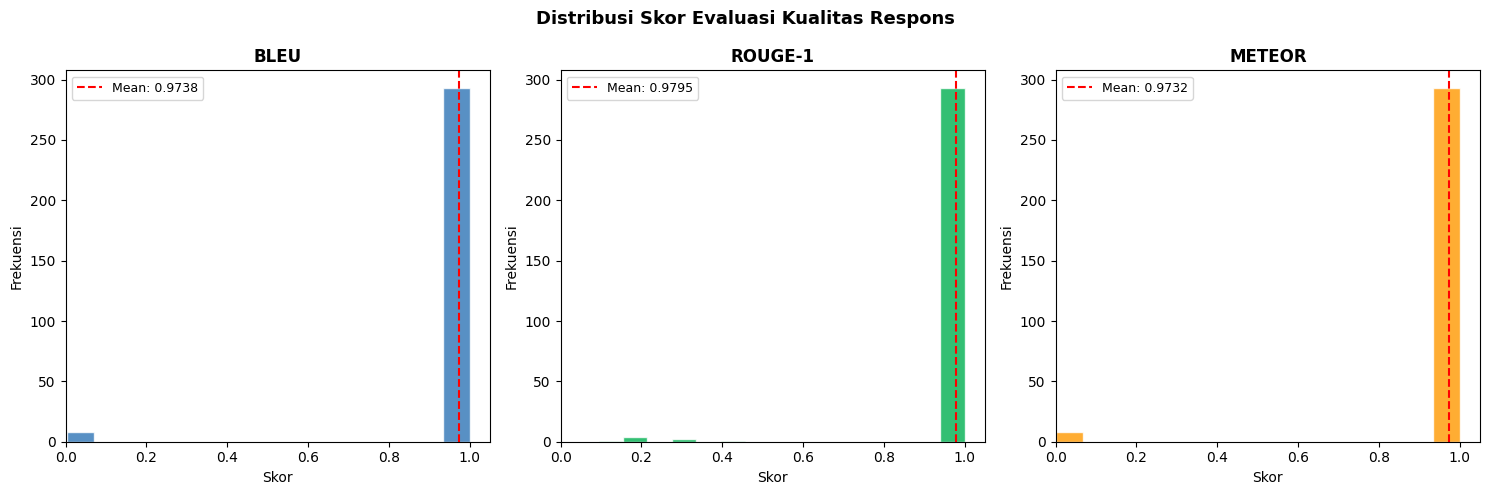

In [ ]:
# Visualisasi distribusi skor BLEU, ROUGE-1, METEOR
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Skor Evaluasi Kualitas Respons', fontsize=13, fontweight='bold')

plot_metrics = [('BLEU','#2E75B6'), ('ROUGE-1','#00B050'), ('METEOR','#FF9900')]
for ax, (metric, color) in zip(axes, plot_metrics):
    vals = eval_df[metric]
    ax.hist(vals, bins=15, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean: {vals.mean():.4f}')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('Skor')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('evaluasi_respons.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Rata-rata skor per intent
print('=== RATA-RATA SKOR EVALUASI PER INTENT ===')
per_intent_eval = eval_df.groupby('Intent Aktual')[metrics].mean().round(4)
display(per_intent_eval.style
    .background_gradient(cmap='RdYlGn', vmin=0, vmax=1)
    .format('{:.4f}')
)

=== RATA-RATA SKOR EVALUASI PER INTENT ===


,BLEU,ROUGE-1,ROUGE-2,ROUGE-L,METEOR
Intent Aktual,,,,,
fallback,0.9689,0.9717,0.9698,0.9707,0.9688
info_jadwal_pelayanan,0.9235,0.9361,0.9264,0.9361,0.9229
info_jadwal_poli,0.9544,0.9704,0.9616,0.9704,0.9533
info_konseling,1.0000,1.0000,1.0000,1.0000,0.9995
info_syarat_daftar,0.9710,0.9759,0.9725,0.9759,0.9705
keluhan_ringan,1.0000,1.0000,1.0000,1.0000,0.9999
salam_pembuka,0.9681,0.9769,0.9704,0.9752,0.9664


# 9. Demo Chatbot

In [ ]:
def chatbot(user_input: str, show_detail: bool = False) -> str:
    """
    Fungsi inferensi chatbot lengkap.

    Alur:
    1. Preprocess input user (6 tahap)
    2. SVM OvO → prediksi intent
    3. Filter training set ke intent yang diprediksi
    4. Cosine similarity dalam intent → utterance paling mirip
    5. Kembalikan jawaban utterance tersebut (dengan emoji, apa adanya)
    """
    clean = full_preprocessing(user_input)

    if not clean.strip():
        return '🙏 Maaf kak, pesan tidak dapat dipahami. Coba tulis ulang ya!'

    # Prediksi intent
    predicted_intent = svm_step.predict(tfidf_step.transform([clean]))[0]

    # Filter training set ke intent yang sama, lalu cosine similarity
    intent_mask  = (df_train['intent'] == predicted_intent).values
    df_intent    = df_train[intent_mask].reset_index(drop=True)
    X_intent     = X_train_tfidf[intent_mask]

    q_vec        = tfidf_step.transform([clean])
    sims         = cosine_similarity(q_vec, X_intent).flatten()
    best_idx     = int(np.argmax(sims))
    best_jawaban = df_intent['jawaban'].iloc[best_idx]
    best_utt     = df_intent['utterance'].iloc[best_idx]
    best_sim     = sims[best_idx]

    if show_detail:
        print(f'  Input          : {user_input}')
        print(f'  Preprocessed   : {clean}')
        print(f'  Intent SVM     : {predicted_intent}')
        print(f'  Utterance mirip: {best_utt}')
        print(f'  Similarity     : {best_sim:.4f}')
        print(f'  Jawaban        : {best_jawaban}')
        print()

    return best_jawaban

print('✅ Fungsi chatbot() diperbarui: filter intent aktif.')
print('   Sekarang jawaban selalu dari intent yang diprediksi.')


✅ Fungsi chatbot() diperbarui: filter intent aktif.
   Sekarang jawaban selalu dari intent yang diprediksi.


In [ ]:
# ── Demo chatbot ─────────────────────────────────────────────────
test_queries = [
    'Puskesmas Cijagra buka jam berapa?',
    'poli gigi jadwal hari apa?',
    'mau daftar berobat, bawa apa aja?',
    'konseling gizi kapan ya?',
    'anak saya demam, ke poli mana?',
    'halo min selamat pagi 😊',
    'ada lowongan kerja tidak?',
    'biaya berobat tanpa BPJS berapa?',
    'imunisasi bayi hari apa?',
    'sabtu masih buka ga puskesmasnya?',
]

print('=' * 65)
print('  DEMO CHATBOT PUSKESMAS CIJAGRA BARU')
print('=' * 65)
for q in test_queries:
    print(f'\n👤 User   : {q}')
    resp = chatbot(q, show_detail=False)
    print(f'🤖 Chatbot: {resp}')
    print('-' * 65)

  DEMO CHATBOT PUSKESMAS CIJAGRA BARU

👤 User   : Puskesmas Cijagra buka jam berapa?
🤖 Chatbot: ⏰ Jam pendaftaran rawat jalan:
• Senin–Kamis : 07.30–12.00 WIB
• Jum'at–Sabtu : 07.30–11.00 WIB
Minggu & libur nasional: TUTUP 😊
-----------------------------------------------------------------

👤 User   : poli gigi jadwal hari apa?
🤖 Chatbot: 🦷 Poli Gigi buka setiap Senin–Sabtu. Pendaftaran mulai 07.30 WIB 😊
-----------------------------------------------------------------

👤 User   : mau daftar berobat, bawa apa aja?
🤖 Chatbot: 📋 Syarat daftar:
• Pasien Umum: KTP atau KK
• Pasien BPJS: KTP/KK + Kartu BPJS aktif 😊
-----------------------------------------------------------------

👤 User   : konseling gizi kapan ya?
🤖 Chatbot: 🥗 Konseling Gizi tersedia setiap Selasa & Kamis, pendaftaran mulai 07.30 WIB 😊
-----------------------------------------------------------------

👤 User   : anak saya demam, ke poli mana?
🤖 Chatbot: 👶 Anak/balita yang sakit ditangani di Poli MTBS ya, tersedia Senin–Sa

# 10. Ringkasan

In [ ]:
print('=' * 60)
print('   RINGKASAN HASIL PENELITIAN')
print('   Chatbot SVM — Puskesmas Cijagra Baru')
print('=' * 60)
print(f'\n📂 DATASET')
print(f'   Total utterances    : {len(df)}')
print(f'   Jumlah intent       : {df["intent"].nunique()}')
print(f'   Split training      : {len(X_train)} sampel (80%)')
print(f'   Split test          : {len(X_test)} sampel (20%)')
print(f'\n⚙️  MODEL')
print(f'   Algoritma           : LinearSVC + OneVsOneClassifier (OvO)')
print(f'   Best C              : {svm_model.C}')
print(f'   Best ngram_range    : {tfidf_step.ngram_range}')
print(f'   Best max_features   : {tfidf_step.max_features}')
print(f'   F1-Macro CV (train) : {grid_search.best_score_:.4f}')
print(f'   Jumlah classifier   : {n_clf_ovo} classifier OvO')
print(f'\n📊 EVALUASI KLASIFIKASI INTENT (test set)')
print(f'   Accuracy            : {acc:.4f}  ({acc*100:.2f}%)')
print(f'   Precision Macro     : {p_macro:.4f}')
print(f'   Recall Macro        : {r_macro:.4f}')
print(f'   F1-Score Macro      : {f1_macro:.4f}')
print(f'\n📝 EVALUASI KUALITAS RESPONS')
for m in metrics:
    v = eval_df[m].mean()
    print(f'   {m:<10}: {v:.4f}  → {interp(v)}')
print(f'\n💾 FILE OUTPUT')
print(f'   chatbot_bundle.pkl')
print(f'   dataset_preprocessed.xlsx')
print('=' * 60)

   RINGKASAN HASIL PENELITIAN
   Chatbot SVM — Puskesmas Cijagra Baru

📂 DATASET
   Total utterances    : 1505
   Jumlah intent       : 7
   Split training      : 1204 sampel (80%)
   Split test          : 301 sampel (20%)

⚙️  MODEL
   Algoritma           : LinearSVC + OneVsOneClassifier (OvO)
   Best C              : 5
   Best ngram_range    : (1, 2)
   Best max_features   : 2000
   F1-Macro CV (train) : 0.9685
   Jumlah classifier   : 21 classifier OvO

📊 EVALUASI KLASIFIKASI INTENT (test set)
   Accuracy            : 0.9734  (97.34%)
   Precision Macro     : 0.9757
   Recall Macro        : 0.9689
   F1-Score Macro      : 0.9721

📝 EVALUASI KUALITAS RESPONS
   BLEU      : 0.9738  → Excellent
   ROUGE-1   : 0.9795  → Excellent
   ROUGE-2   : 0.9757  → Excellent
   ROUGE-L   : 0.9792  → Excellent
   METEOR    : 0.9732  → Excellent

💾 FILE OUTPUT
   chatbot_bundle.pkl
   dataset_preprocessed.xlsx


# Perbandingan

1. **OvO vs OvR** — Strategi klasifikasi multi-kelas
2. **Hyperparameter C** — Pengaruh regularisasi terhadap performa
3. **ngram_range** — Unigram vs Bigram pada TF-IDF
4. **SVM vs Naïve Bayes vs Random Forest** — Perbandingan algoritma

## PERBANDINGAN 1 — OvO vs OvR
### (Strategi Klasifikasi Multi-kelas)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier
import time
from sklearn.model_selection import cross_val_score

# === Parameter terbaik dari GridSearchCV (notebook utama) ===
# CATATAN KONSISTENSI: seluruh studi ablation di bawah (OvO/OvR, nilai C,
# ngram, algoritma) menahan SEMUA parameter lain pada nilai PEMENANG
# GridSearch, sehinggga kesimpulan tabel konsisten dengan model final.
BEST_C        = 5
BEST_NGRAM    = (1, 2)
BEST_MAX_FEAT = 2000
BEST_MAX_ITER = 1000

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Model OvO (model utama yang dipilih) ---
pipeline_ovo = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=BEST_NGRAM, max_features=BEST_MAX_FEAT)),
    ('svm',   OneVsOneClassifier(
        LinearSVC(C=BEST_C, class_weight='balanced',
                  max_iter=BEST_MAX_ITER, random_state=42)
    ))
])

# --- Model OvR (pembanding) ---
pipeline_ovr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=BEST_NGRAM, max_features=BEST_MAX_FEAT)),
    ('svm',   OneVsRestClassifier(
        LinearSVC(C=BEST_C, class_weight='balanced',
                  max_iter=BEST_MAX_ITER, random_state=42)
    ))
])

print('Training OvO dan OvR dengan parameter identik (pemenang GridSearch)...')
print(f'  C={BEST_C}, ngram={BEST_NGRAM}, max_features={BEST_MAX_FEAT}, max_iter={BEST_MAX_ITER}')

t0 = time.time()
pipeline_ovo.fit(X_train, y_train)
time_ovo = time.time() - t0
y_pred_ovo = pipeline_ovo.predict(X_test)

t0 = time.time()
pipeline_ovr.fit(X_train, y_train)
time_ovr = time.time() - t0
y_pred_ovr = pipeline_ovr.predict(X_test)

cv_ovo = cross_val_score(pipeline_ovo, X_train, y_train, cv=cv, scoring='f1_macro')
cv_ovr = cross_val_score(pipeline_ovr, X_train, y_train, cv=cv, scoring='f1_macro')

# Jumlah classifier dihitung otomatis: OvO = k(k-1)/2 ; OvR = k
_k = len(np.unique(y_train))
N_CLF_OVO = _k * (_k - 1) // 2
N_CLF_OVR = _k

print('Selesai!')

Training OvO dan OvR dengan parameter identik (pemenang GridSearch)...
  C=5, ngram=(1, 2), max_features=2000, max_iter=1000
Selesai!


In [ ]:
# --- Tabel Perbandingan Global ---
results = {
    'OvO (One-vs-One)': {
        'Accuracy'       : accuracy_score(y_test, y_pred_ovo),
        'Precision Macro': precision_score(y_test, y_pred_ovo, average='macro', zero_division=0),
        'Recall Macro'   : recall_score(y_test, y_pred_ovo, average='macro', zero_division=0),
        'F1-Score Macro' : f1_score(y_test, y_pred_ovo, average='macro', zero_division=0),
        'F1-CV Mean'     : cv_ovo.mean(),
        'F1-CV Std'      : cv_ovo.std(),
        'Jumlah Classifier': N_CLF_OVO,
        'Waktu Training (s)': round(time_ovo, 3),
    },
    'OvR (One-vs-Rest)': {
        'Accuracy'       : accuracy_score(y_test, y_pred_ovr),
        'Precision Macro': precision_score(y_test, y_pred_ovr, average='macro', zero_division=0),
        'Recall Macro'   : recall_score(y_test, y_pred_ovr, average='macro', zero_division=0),
        'F1-Score Macro' : f1_score(y_test, y_pred_ovr, average='macro', zero_division=0),
        'F1-CV Mean'     : cv_ovr.mean(),
        'F1-CV Std'      : cv_ovr.std(),
        'Jumlah Classifier': N_CLF_OVR,
        'Waktu Training (s)': round(time_ovr, 3),
    }
}

df_compare = pd.DataFrame(results).T
df_compare_display = df_compare.copy()
for col in ['Accuracy','Precision Macro','Recall Macro','F1-Score Macro','F1-CV Mean','F1-CV Std']:
    df_compare_display[col] = df_compare[col].apply(lambda x: f'{float(x):.4f}')

print('\n=== TABEL PERBANDINGAN OvO vs OvR ===')
display(df_compare_display.style
    .set_caption(f'Perbandingan Strategi OvO vs OvR dengan parameter identik (C={BEST_C}, ngram={BEST_NGRAM}, max_features={BEST_MAX_FEAT})')
    .set_properties(**{'text-align':'center'})
    .apply(lambda col: ['background-color: #E2F0E8; font-weight:bold'
                        if col.name == 'OvO (One-vs-One)' else '' for _ in col], axis=0)
)


=== TABEL PERBANDINGAN OvO vs OvR ===


,Accuracy,Precision Macro,Recall Macro,F1-Score Macro,F1-CV Mean,F1-CV Std,Jumlah Classifier,Waktu Training (s)
OvO (One-vs-One),0.9734,0.9757,0.9689,0.9721,0.9685,0.0109,21.000000,0.112000
OvR (One-vs-Rest),0.9734,0.9789,0.9678,0.9728,0.9694,0.0120,7.000000,0.133000


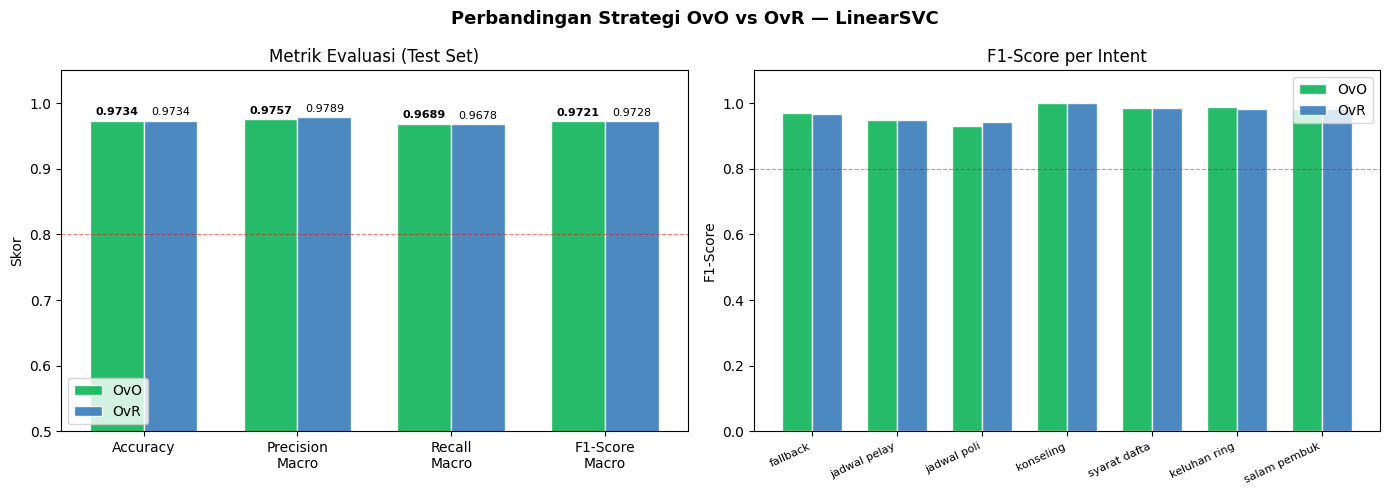


=== F1-SCORE PER INTENT ===


,Intent,F1 OvO,F1 OvR,Selisih,Keterangan
0,fallback,0.9688,0.9677,+0.0010,OvO lebih baik
1,info_jadwal_pelayanan,0.9474,0.9474,+0.0000,Sama
2,info_jadwal_poli,0.9318,0.9438,-0.0120,OvR lebih baik
3,info_konseling,1.0000,1.0000,+0.0000,Sama
4,info_syarat_daftar,0.9851,0.9851,+0.0000,Sama
5,keluhan_ringan,0.9885,0.9829,+0.0056,OvO lebih baik
6,salam_pembuka,0.9831,0.9831,+0.0000,Sama


In [ ]:
# ── Visualisasi 1: Bar chart perbandingan metrik ──────────────────────────
metrik_labels = ['Accuracy', 'Precision\nMacro', 'Recall\nMacro', 'F1-Score\nMacro']
metrik_keys   = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Score Macro']

ovo_vals = [float(df_compare.loc['OvO (One-vs-One)', k]) for k in metrik_keys]
ovr_vals = [float(df_compare.loc['OvR (One-vs-Rest)', k]) for k in metrik_keys]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Strategi OvO vs OvR — LinearSVC', fontsize=13, fontweight='bold')

# Panel kiri: grouped bar chart
x = np.arange(len(metrik_labels))
w = 0.35
bars1 = axes[0].bar(x - w/2, ovo_vals, w, label='OvO', color='#00B050', alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x + w/2, ovr_vals, w, label='OvR', color='#2E75B6', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrik_labels, fontsize=10)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Skor')
axes[0].set_title('Metrik Evaluasi (Test Set)')
axes[0].legend()
axes[0].axhline(y=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Threshold 0.80')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

# Panel kanan: F1 per-intent comparison
labels = sorted(y.unique())
report_ovo = classification_report(y_test, y_pred_ovo, labels=labels, output_dict=True, zero_division=0)
report_ovr = classification_report(y_test, y_pred_ovr, labels=labels, output_dict=True, zero_division=0)

f1_ovo_per = [report_ovo[l]['f1-score'] for l in labels]
f1_ovr_per = [report_ovr[l]['f1-score'] for l in labels]

short_labels = [l.replace('info_','').replace('_',' ')[:12] for l in labels]
x2 = np.arange(len(labels))
axes[1].bar(x2 - w/2, f1_ovo_per, w, label='OvO', color='#00B050', alpha=0.85, edgecolor='white')
axes[1].bar(x2 + w/2, f1_ovr_per, w, label='OvR', color='#2E75B6', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(short_labels, rotation=25, ha='right', fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score per Intent')
axes[1].legend()
axes[1].axhline(y=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('perbandingan_ovo_ovr.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabel F1 per-intent
df_per_intent = pd.DataFrame({
    'Intent'    : labels,
    'F1 OvO'    : [f'{v:.4f}' for v in f1_ovo_per],
    'F1 OvR'    : [f'{v:.4f}' for v in f1_ovr_per],
    'Selisih'   : [f'+{(a-b):.4f}' if a>=b else f'{(a-b):.4f}' for a,b in zip(f1_ovo_per,f1_ovr_per)],
    'Keterangan': ['OvO lebih baik' if a>b else ('Sama' if a==b else 'OvR lebih baik')
                   for a,b in zip(f1_ovo_per,f1_ovr_per)]
})
print('\n=== F1-SCORE PER INTENT ===')
display(df_per_intent)

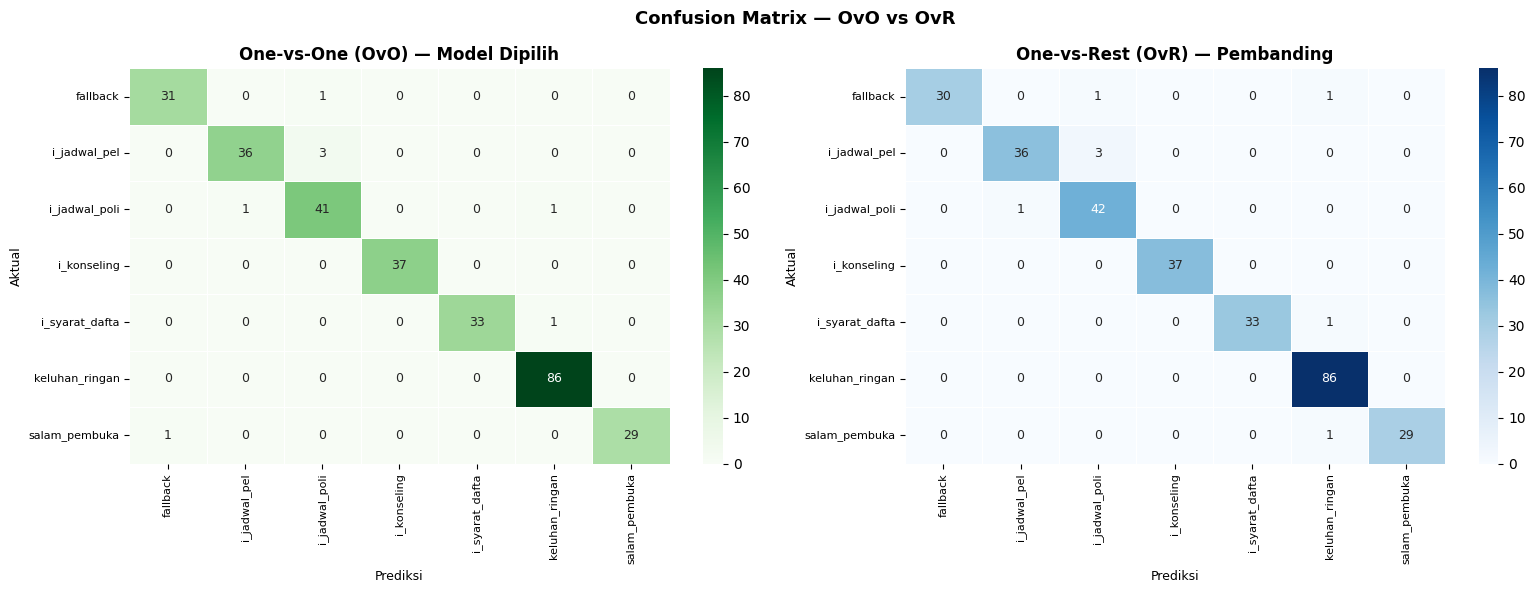

In [ ]:
# ── Visualisasi 2: Confusion Matrix berdampingan ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — OvO vs OvR', fontsize=13, fontweight='bold')

short = [l.replace('info_','i_').replace('_pelayanan','_pel')[:14] for l in labels]

for ax, y_p, title, cmap in zip(
    axes,
    [y_pred_ovo, y_pred_ovr],
    ['One-vs-One (OvO) — Model Dipilih', 'One-vs-Rest (OvR) — Pembanding'],
    ['Greens', 'Blues']
):
    cm = confusion_matrix(y_test, y_p, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=short, yticklabels=short,
                linewidths=0.5, ax=ax, annot_kws={'size':9})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual', fontsize=9)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('confusion_matrix_ovo_ovr.png', dpi=150, bbox_inches='tight')
plt.show()

## PERBANDINGAN 2 — Pengaruh Hyperparameter C


In [ ]:
# Perbandingan nilai C dengan parameter LAIN ditahan di pemenang GridSearch
# (ngram=(1,2), max_features=2000, OvO). Kolom 'Keterangan' kini ditentukan
# DARI DATA (F1-CV tertinggi), bukan anotasi manual. Dengan begitu 'C terbaik'
# pada tabel ini konsisten dengan pilihan GridSearchCV.
C_values   = [0.01, 0.1, 5]
C_results  = []

tfidf_base = TfidfVectorizer(ngram_range=BEST_NGRAM, max_features=BEST_MAX_FEAT)
X_tr_tfidf = tfidf_base.fit_transform(X_train)
X_te_tfidf = tfidf_base.transform(X_test)

for C in C_values:
    model = OneVsOneClassifier(
        LinearSVC(C=C, class_weight='balanced', max_iter=BEST_MAX_ITER, random_state=42)
    )
    cv_scores = cross_val_score(model, X_tr_tfidf, y_train, cv=cv, scoring='f1_macro')
    model.fit(X_tr_tfidf, y_train)
    y_pred_c = model.predict(X_te_tfidf)
    C_results.append({
        'C'            : C,
        'F1-CV Mean'   : cv_scores.mean(),
        'F1-CV Std'    : cv_scores.std(),
        'Accuracy Test': accuracy_score(y_test, y_pred_c),
        'F1-Macro Test': f1_score(y_test, y_pred_c, average='macro', zero_division=0),
    })
    print(f'C={C:<5} | F1-CV: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} | F1-Test: {C_results[-1]["F1-Macro Test"]:.4f}')

df_c = pd.DataFrame(C_results)
# Label data-driven berdasarkan F1-CV
_best  = df_c['F1-CV Mean'].idxmax()
_worst = df_c['F1-CV Mean'].idxmin()
df_c['Keterangan'] = 'Regularisasi menengah'
df_c.loc[_best,  'Keterangan'] = 'F1-CV tertinggi (konsisten dgn GridSearch)'
df_c.loc[_worst, 'Keterangan'] = 'F1-CV terendah (regularisasi terlalu kuat)'

print('\n=== TABEL PERBANDINGAN NILAI C ===')
display(df_c.style
    .format({'F1-CV Mean':'{:.4f}','F1-CV Std':'{:.4f}','Accuracy Test':'{:.4f}','F1-Macro Test':'{:.4f}'})
    .apply(lambda row: ['background-color: #000000; font-weight:bold']*len(row)
                       if row.name==_best else ['']*len(row), axis=1)
    .set_caption(f'Pengaruh nilai C terhadap F1-Macro (OvO, ngram={BEST_NGRAM}, max_features={BEST_MAX_FEAT})')
)

C=0.01  | F1-CV: 0.8693 +/- 0.0179 | F1-Test: 0.8974
C=0.1   | F1-CV: 0.9197 +/- 0.0141 | F1-Test: 0.9407
C=5     | F1-CV: 0.9638 +/- 0.0095 | F1-Test: 0.9721

=== TABEL PERBANDINGAN NILAI C ===


,C,F1-CV Mean,F1-CV Std,Accuracy Test,F1-Macro Test,Keterangan
0,0.010000,0.8693,0.0179,0.9070,0.8974,F1-CV terendah (regularisasi terlalu kuat)
1,0.100000,0.9197,0.0141,0.9468,0.9407,Regularisasi menengah
2,5.000000,0.9638,0.0095,0.9734,0.9721,F1-CV tertinggi (konsisten dgn GridSearch)


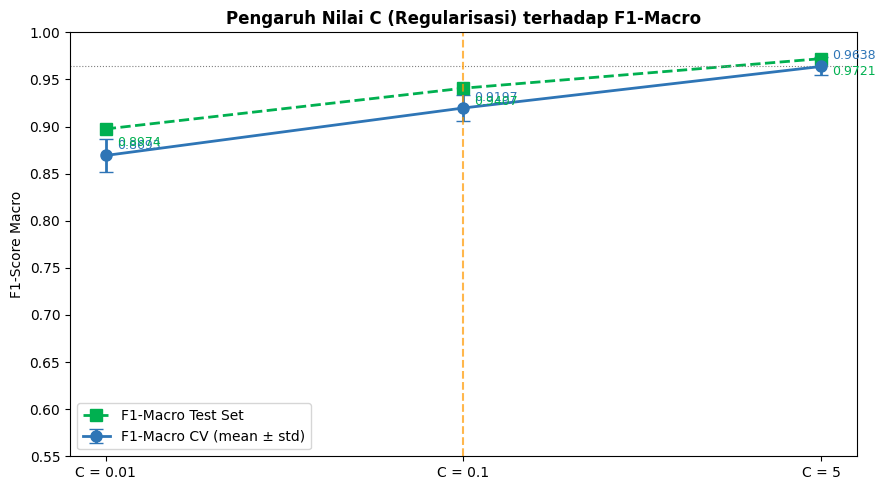

In [ ]:
# ── Visualisasi: Line plot F1-CV dan F1-Test per nilai C ─────────────────
fig, ax = plt.subplots(figsize=(9, 5))

c_vals    = [r['C'] for r in C_results]
f1_cv     = [r['F1-CV Mean'] for r in C_results]
f1_cv_std = [r['F1-CV Std'] for r in C_results]
f1_test   = [r['F1-Macro Test'] for r in C_results]

ax.errorbar(range(len(c_vals)), f1_cv, yerr=f1_cv_std,
            marker='o', color='#2E75B6', linewidth=2,
            capsize=5, label='F1-Macro CV (mean ± std)', markersize=8)
ax.plot(range(len(c_vals)), f1_test,
        marker='s', color='#00B050', linewidth=2,
        linestyle='--', label='F1-Macro Test Set', markersize=8)

ax.set_xticks(range(len(c_vals)))
ax.set_xticklabels([f'C = {c}' for c in c_vals], fontsize=10)
ax.set_ylim(0.55, 1.0)
ax.set_ylabel('F1-Score Macro')
ax.set_title('Pengaruh Nilai C (Regularisasi) terhadap F1-Macro', fontweight='bold')
ax.legend()
ax.axhline(y=max(f1_cv), color='gray', linestyle=':', linewidth=0.8)
ax.axvline(x=1, color='#FF9900', linestyle='--', linewidth=1.5, alpha=0.7, label='C optimal')

# Anotasi tiap titik
for i, (cv_v, test_v) in enumerate(zip(f1_cv, f1_test)):
    ax.annotate(f'{cv_v:.4f}', (i, cv_v), textcoords='offset points', xytext=(8,5), fontsize=9, color='#2E75B6')
    ax.annotate(f'{test_v:.4f}', (i, test_v), textcoords='offset points', xytext=(8,-12), fontsize=9, color='#00B050')

plt.tight_layout()
plt.savefig('perbandingan_nilai_c.png', dpi=150, bbox_inches='tight')
plt.show()

## PERBANDINGAN 3 — Unigram (1,1) vs Bigram (1,2)

In [ ]:
# Perbandingan ngram dengan parameter LAIN ditahan di pemenang GridSearch
# (C=5, max_features=2000, OvO). Ini penting: pada notebook sebelumnya tabel
# ini dijalankan pada C=0.1/max_features=500 sehingga (1,1) terlihat 'menang',
# padahal pada konfigurasi final (C=5, 2000 fitur) GridSearch memilih (1,2).
ngram_configs = [(1,1), (1,2)]
ngram_results = []

for ngram in ngram_configs:
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=ngram, max_features=BEST_MAX_FEAT)),
        ('svm',   OneVsOneClassifier(
            LinearSVC(C=BEST_C, class_weight='balanced', max_iter=BEST_MAX_ITER, random_state=42)
        ))
    ])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro')
    pipe.fit(X_train, y_train)
    y_p = pipe.predict(X_test)
    n_features = len(pipe.named_steps['tfidf'].get_feature_names_out())
    ngram_results.append({
        'ngram_range'  : str(ngram),
        'Tipe Fitur'   : 'Unigram' if ngram==(1,1) else 'Unigram + Bigram',
        'Jumlah Fitur' : n_features,
        'F1-CV Mean'   : cv_scores.mean(),
        'F1-CV Std'    : cv_scores.std(),
        'Accuracy Test': accuracy_score(y_test, y_p),
        'F1-Macro Test': f1_score(y_test, y_p, average='macro', zero_division=0),
    })
    print(f'ngram{ngram} ({n_features} fitur) | F1-CV: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f} | F1-Test: {ngram_results[-1]["F1-Macro Test"]:.4f}')

df_ngram = pd.DataFrame(ngram_results)
_bn = df_ngram['F1-CV Mean'].idxmax()
df_ngram['Keterangan'] = 'Pembanding'
df_ngram.loc[_bn, 'Keterangan'] = 'F1-CV tertinggi (konsisten dgn GridSearch)'

print('\n=== TABEL PERBANDINGAN NGRAM ===')
display(df_ngram.style
    .format({'F1-CV Mean':'{:.4f}','F1-CV Std':'{:.4f}','Accuracy Test':'{:.4f}','F1-Macro Test':'{:.4f}'})
    .apply(lambda row: ['background-color: #000000; font-weight:bold']*len(row)
                       if row.name==_bn else ['']*len(row), axis=1)
    .set_caption(f'Perbandingan Unigram vs Bigram (C={BEST_C}, max_features={BEST_MAX_FEAT}, OvO)')
)

ngram(1, 1) (476 fitur) | F1-CV: 0.9651 +/- 0.0072 | F1-Test: 0.9733
ngram(1, 2) (1736 fitur) | F1-CV: 0.9685 +/- 0.0109 | F1-Test: 0.9721

=== TABEL PERBANDINGAN NGRAM ===


,ngram_range,Tipe Fitur,Jumlah Fitur,F1-CV Mean,F1-CV Std,Accuracy Test,F1-Macro Test,Keterangan
0,"(1, 1)",Unigram,476,0.9651,0.0072,0.9734,0.9733,Pembanding
1,"(1, 2)",Unigram + Bigram,1736,0.9685,0.0109,0.9734,0.9721,F1-CV tertinggi (konsisten dgn GridSearch)


##  PERBANDINGAN 4 — SVM vs Naïve Bayes vs Random Forest

In [ ]:
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier

# TF-IDF bersama disamakan dengan konfigurasi final (pemenang GridSearch)
tfidf_shared = TfidfVectorizer(ngram_range=BEST_NGRAM, max_features=BEST_MAX_FEAT)
X_tr = tfidf_shared.fit_transform(X_train)
X_te = tfidf_shared.transform(X_test)

models_compare = [
    ('SVM LinearSVC (OvO)',
     OneVsOneClassifier(LinearSVC(C=BEST_C, class_weight='balanced', max_iter=BEST_MAX_ITER, random_state=42))),
    ('Naive Bayes (Complement NB)',
     ComplementNB(alpha=0.1)),
    ('Random Forest',
     RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
]

algo_results = []
for name, model in models_compare:
    t0 = time.time()
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='f1_macro')
    model.fit(X_tr, y_train)
    train_time = time.time() - t0
    y_p = model.predict(X_te)
    algo_results.append({
        'Algoritma'      : name,
        'Accuracy'       : accuracy_score(y_test, y_p),
        'Precision Macro': precision_score(y_test, y_p, average='macro', zero_division=0),
        'Recall Macro'   : recall_score(y_test, y_p, average='macro', zero_division=0),
        'F1-Macro Test'  : f1_score(y_test, y_p, average='macro', zero_division=0),
        'F1-CV Mean'     : cv_scores.mean(),
        'F1-CV Std'      : cv_scores.std(),
        'Waktu (s)'      : round(train_time, 3),
    })
    print(f'{name[:35]:35} | Acc: {accuracy_score(y_test,y_p):.4f} | F1-Test: {f1_score(y_test,y_p,average="macro",zero_division=0):.4f} | F1-CV: {cv_scores.mean():.4f}+/-{cv_scores.std():.4f}')

df_algo = pd.DataFrame(algo_results)
print('\n=== TABEL PERBANDINGAN ALGORITMA ===')
display(df_algo.style
    .format({'Accuracy':'{:.4f}','Precision Macro':'{:.4f}',
             'Recall Macro':'{:.4f}','F1-Macro Test':'{:.4f}',
             'F1-CV Mean':'{:.4f}','F1-CV Std':'{:.4f}'})
    .apply(lambda row: ['font-weight:bold']*len(row)
                       if 'SVM' in row['Algoritma'] else ['']*len(row), axis=1)
    .set_caption(f'Perbandingan algoritma dengan TF-IDF identik (ngram={BEST_NGRAM}, max_features={BEST_MAX_FEAT})')
)

SVM LinearSVC (OvO)                 | Acc: 0.9734 | F1-Test: 0.9721 | F1-CV: 0.9638+/-0.0095
Naive Bayes (Complement NB)         | Acc: 0.9734 | F1-Test: 0.9702 | F1-CV: 0.9503+/-0.0189
Random Forest                       | Acc: 0.9269 | F1-Test: 0.9227 | F1-CV: 0.9294+/-0.0164

=== TABEL PERBANDINGAN ALGORITMA ===


,Algoritma,Accuracy,Precision Macro,Recall Macro,F1-Macro Test,F1-CV Mean,F1-CV Std,Waktu (s)
0,SVM LinearSVC (OvO),0.9734,0.9757,0.9689,0.9721,0.9638,0.0095,0.693000
1,Naive Bayes (Complement NB),0.9734,0.9716,0.9689,0.9702,0.9503,0.0189,0.091000
2,Random Forest,0.9269,0.9320,0.9174,0.9227,0.9294,0.0164,6.592000


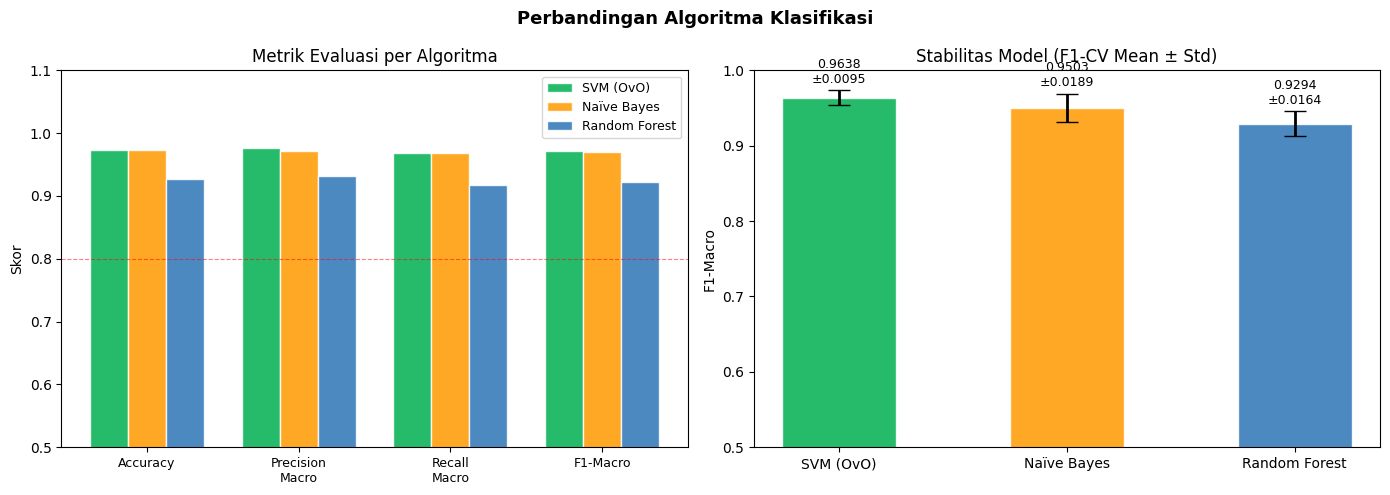

In [ ]:
# ── Visualisasi radar chart perbandingan algoritma ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Perbandingan Algoritma Klasifikasi', fontsize=13, fontweight='bold')

# Panel kiri: grouped bar chart semua metrik
algo_names_short = ['SVM\n(OvO)', 'Naïve\nBayes', 'Random\nForest']
metrics_show = ['Accuracy', 'Precision Macro', 'Recall Macro', 'F1-Macro Test']
colors_algo  = ['#00B050', '#FF9900', '#2E75B6']

x = np.arange(len(metrics_show))
w = 0.25
for idx, (row, color, label) in enumerate(zip(algo_results, colors_algo, algo_names_short)):
    vals = [row[m] for m in metrics_show]
    offset = (idx - 1) * w
    bars = axes[0].bar(x + offset, vals, w, label=label.replace('\n',' '),
                       color=color, alpha=0.85, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(['Accuracy','Precision\nMacro','Recall\nMacro','F1-Macro'], fontsize=9)
axes[0].set_ylim(0.5, 1.1)
axes[0].set_ylabel('Skor')
axes[0].set_title('Metrik Evaluasi per Algoritma')
axes[0].legend(fontsize=9)
axes[0].axhline(y=0.8, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

# Panel kanan: F1-CV mean dengan error bar (stabililtas)
f1_cv_means = [r['F1-CV Mean'] for r in algo_results]
f1_cv_stds  = [r['F1-CV Std'] for r in algo_results]
x2 = np.arange(len(algo_names_short))
axes[1].bar(x2, f1_cv_means, color=colors_algo, alpha=0.85, edgecolor='white', width=0.5)
axes[1].errorbar(x2, f1_cv_means, yerr=f1_cv_stds, fmt='none',
                 color='black', capsize=8, linewidth=2)
axes[1].set_xticks(x2)
axes[1].set_xticklabels([s.replace('\n',' ') for s in algo_names_short])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('F1-Macro')
axes[1].set_title('Stabilitas Model (F1-CV Mean ± Std)')
for i, (m, s) in enumerate(zip(f1_cv_means, f1_cv_stds)):
    axes[1].text(i, m + s + 0.01, f'{m:.4f}\n±{s:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('perbandingan_algoritma.png', dpi=150, bbox_inches='tight')
plt.show()

## RINGKASAN SEMUA PERBANDINGAN

In [ ]:
print('=' * 70)
print('   RINGKASAN PERBANDINGAN - BAB 4.2 PEMBAHASAN')
print('=' * 70)

print('\n1. OvO vs OvR (strategi multi-kelas):')
_ovo_f1 = float(df_compare.loc["OvO (One-vs-One)","F1-Score Macro"])
_ovr_f1 = float(df_compare.loc["OvR (One-vs-Rest)","F1-Score Macro"])
print(f'   OvO F1-Macro : {_ovo_f1:.4f}')
print(f'   OvR F1-Macro : {_ovr_f1:.4f}')
_delta = _ovo_f1 - _ovr_f1
_win = 'OvO' if _delta >= 0 else 'OvR'
print(f'   Selisih      : {_delta:+.4f} ({_delta*100:+.2f}%) -> {_win} lebih unggul/setara')

print('\n2. Hyperparameter C terbaik (berdasarkan F1-CV):')
best_c_row = max(C_results, key=lambda x: x['F1-CV Mean'])
print(f'   C optimal    : {best_c_row["C"]} (F1-CV: {best_c_row["F1-CV Mean"]:.4f})')

print('\n3. ngram_range terbaik (berdasarkan F1-CV):')
best_ngram = max(ngram_results, key=lambda x: x['F1-CV Mean'])
print(f'   ngram optimal: {best_ngram["ngram_range"]} - {best_ngram["Tipe Fitur"]} (F1-CV: {best_ngram["F1-CV Mean"]:.4f})')

print('\n4. Perbandingan algoritma:')
for r in algo_results:
    print(f'   {r["Algoritma"][:35]:35} | F1-Test: {r["F1-Macro Test"]:.4f} | F1-CV: {r["F1-CV Mean"]:.4f}+/-{r["F1-CV Std"]:.4f}')

# Kesimpulan disusun OTOMATIS dari hasil ablation -> selalu konsisten dgn GridSearch
print('\n-> Kesimpulan: SVM strategi OvO dengan '
      f'C={best_c_row["C"]}, ngram={best_ngram["ngram_range"]} '
      f'({best_ngram["Tipe Fitur"]}), max_features={BEST_MAX_FEAT}')
print('   adalah konfigurasi terbaik - konsisten dengan pemenang GridSearchCV.')
print('=' * 70)

   RINGKASAN PERBANDINGAN - BAB 4.2 PEMBAHASAN

1. OvO vs OvR (strategi multi-kelas):
   OvO F1-Macro : 0.9721
   OvR F1-Macro : 0.9728
   Selisih      : -0.0008 (-0.08%) -> OvR lebih unggul/setara

2. Hyperparameter C terbaik (berdasarkan F1-CV):
   C optimal    : 5 (F1-CV: 0.9638)

3. ngram_range terbaik (berdasarkan F1-CV):
   ngram optimal: (1, 2) - Unigram + Bigram (F1-CV: 0.9685)

4. Perbandingan algoritma:
   SVM LinearSVC (OvO)                 | F1-Test: 0.9721 | F1-CV: 0.9638+/-0.0095
   Naive Bayes (Complement NB)         | F1-Test: 0.9702 | F1-CV: 0.9503+/-0.0189
   Random Forest                       | F1-Test: 0.9227 | F1-CV: 0.9294+/-0.0164

-> Kesimpulan: SVM strategi OvO dengan C=5, ngram=(1, 2) (Unigram + Bigram), max_features=2000
   adalah konfigurasi terbaik - konsisten dengan pemenang GridSearchCV.
